In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

# Dataset 1 - Grouping of Master Dataset by Loan Grade

The loan grade grouping was arbitrary, it was chosen by grouping:
- ABC: Grade 0 (Superior)
- DEFG: Grade 1 (Inferior)



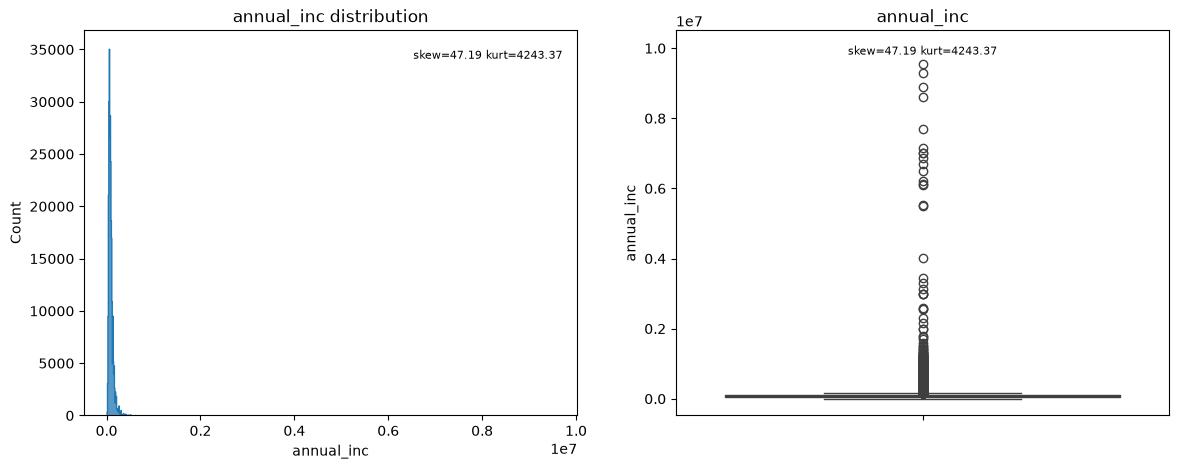

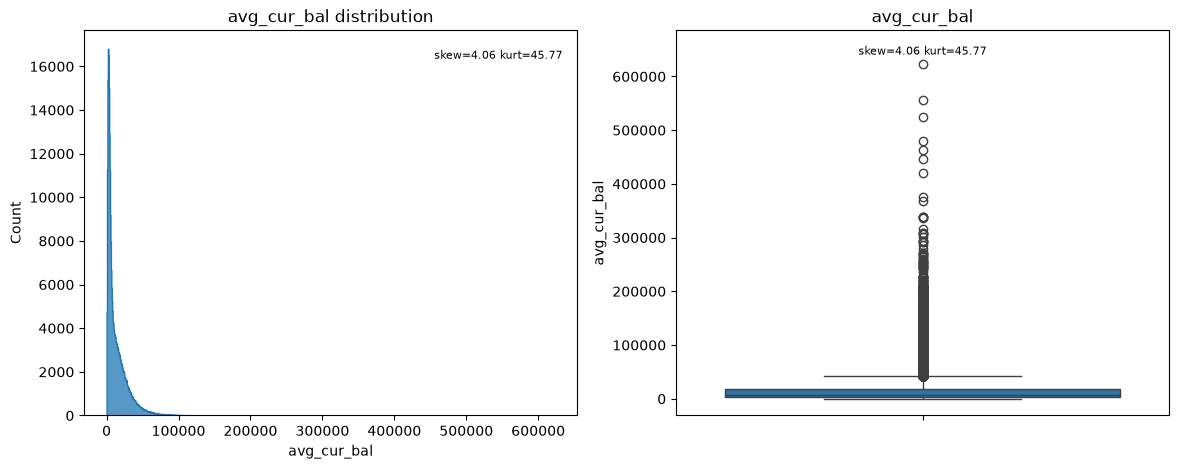

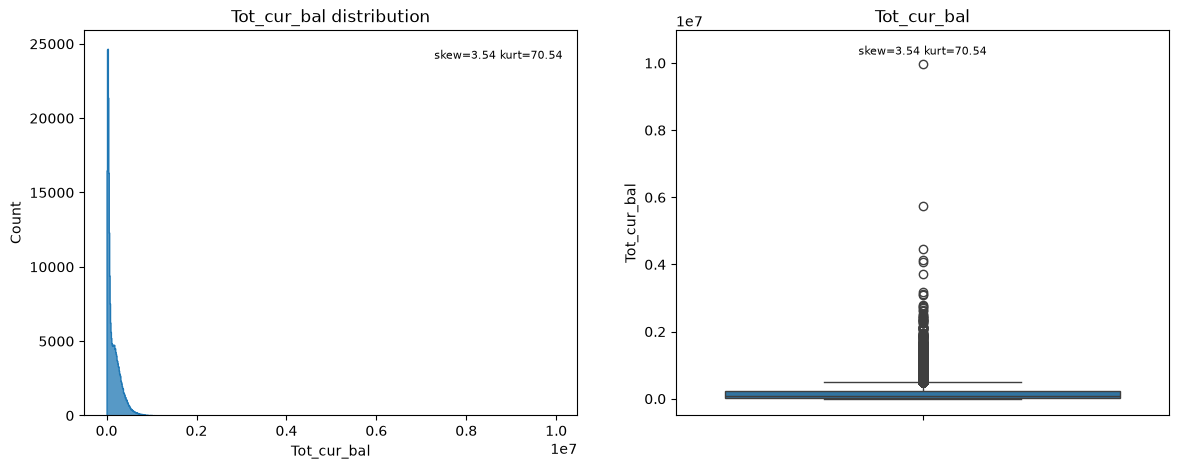

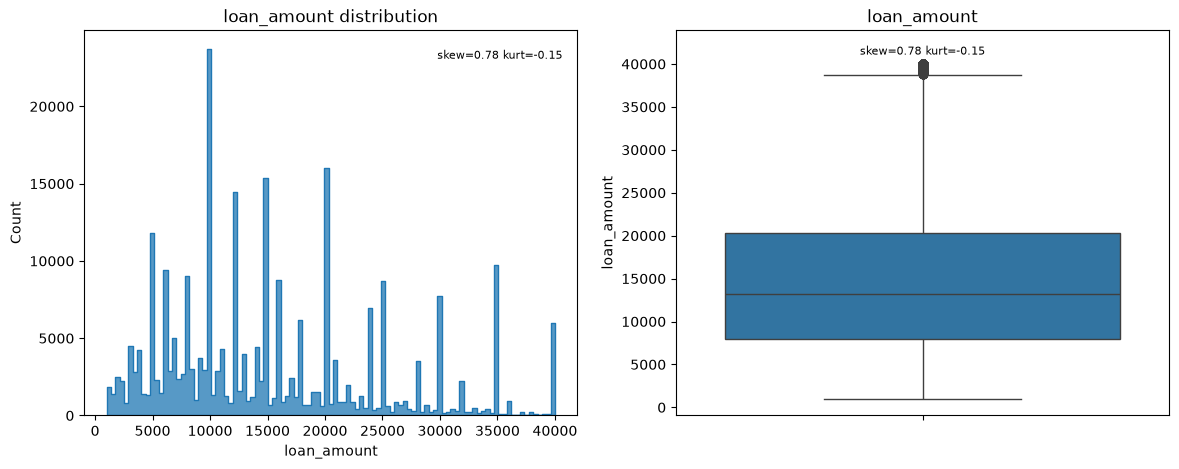

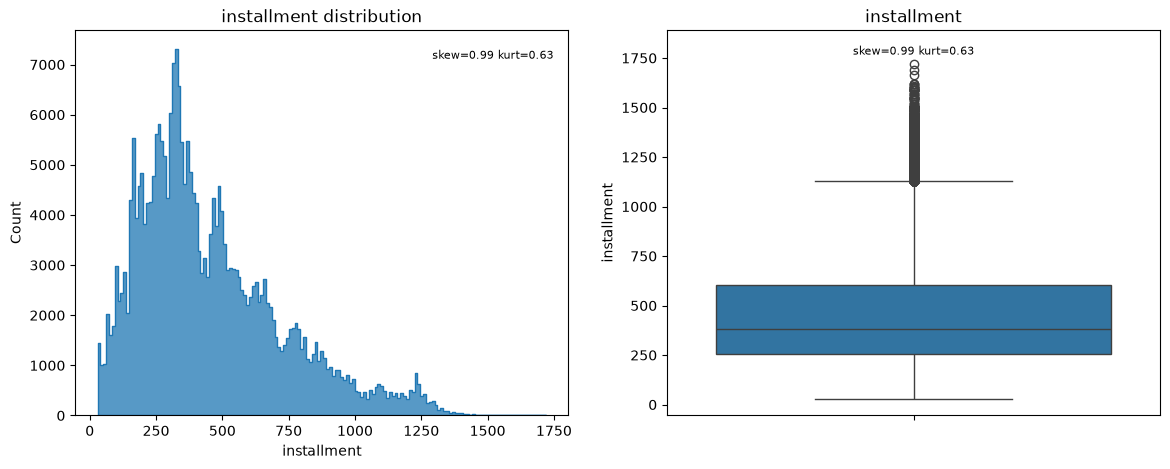

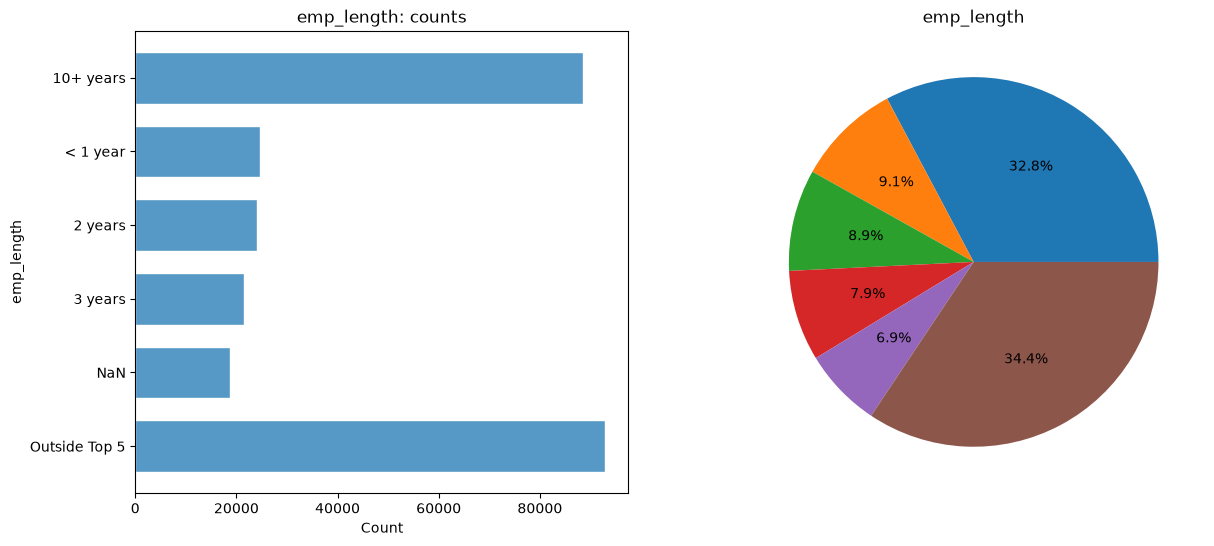

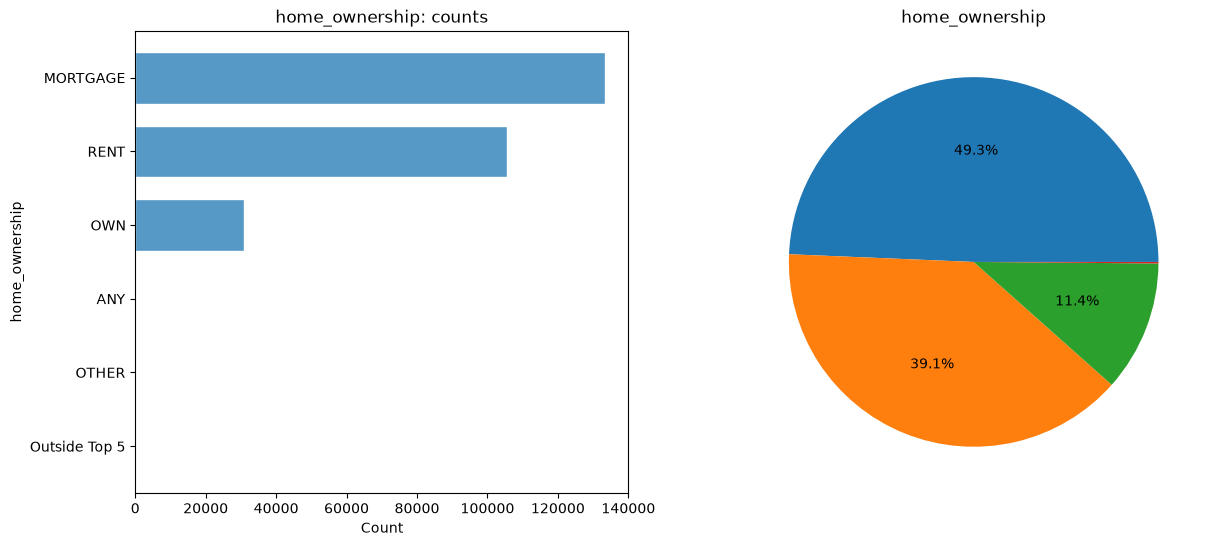

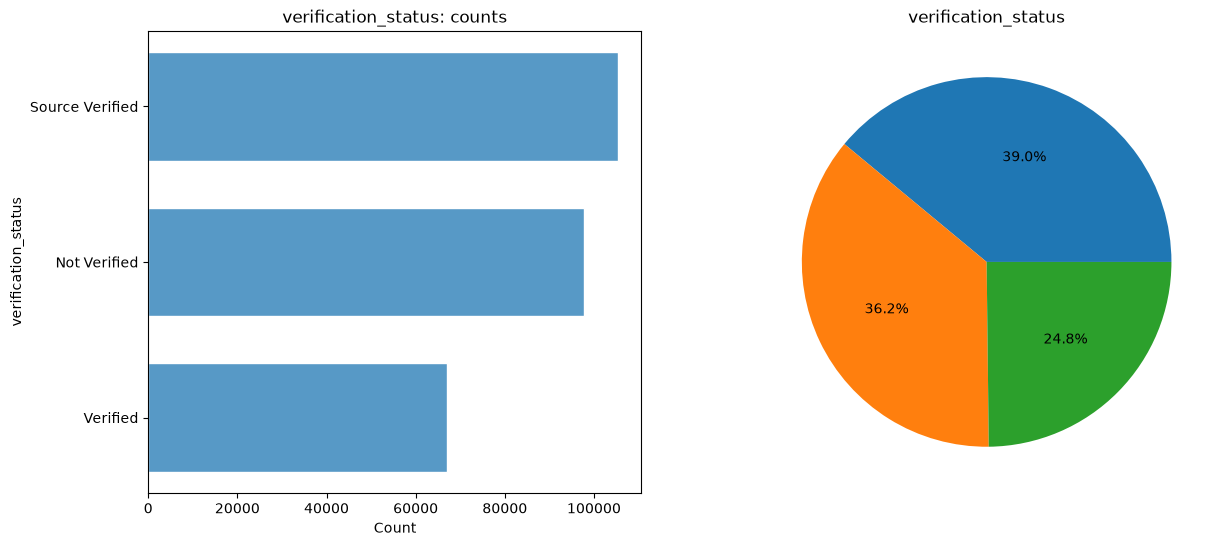

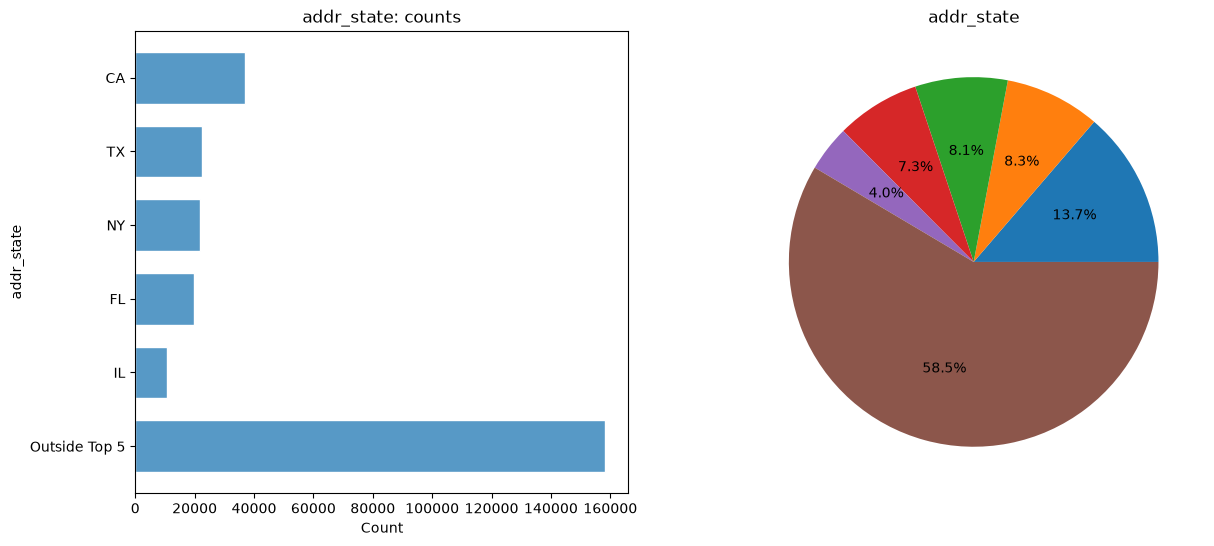

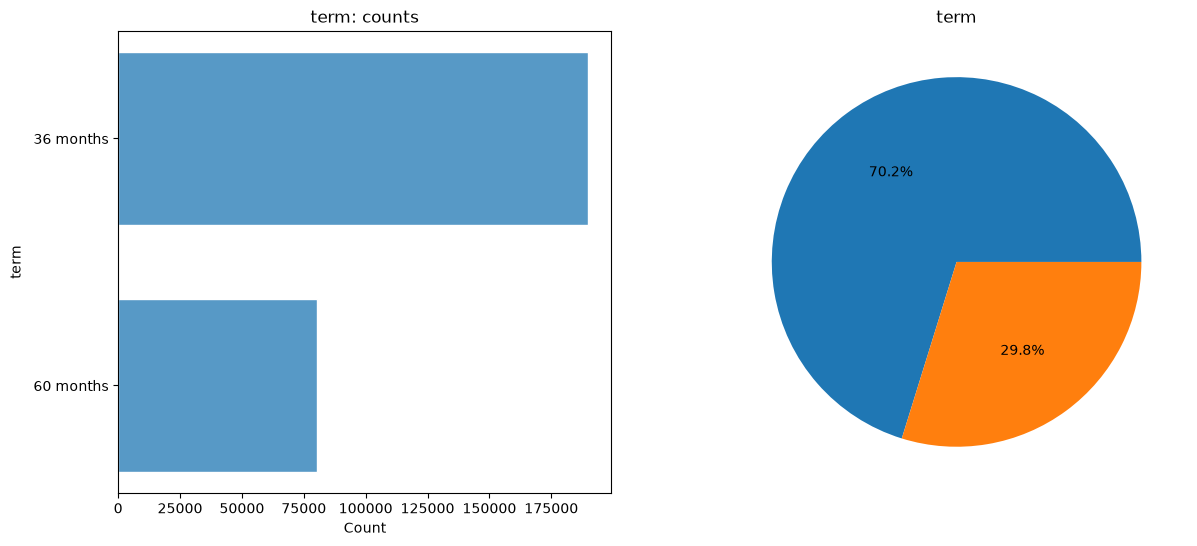

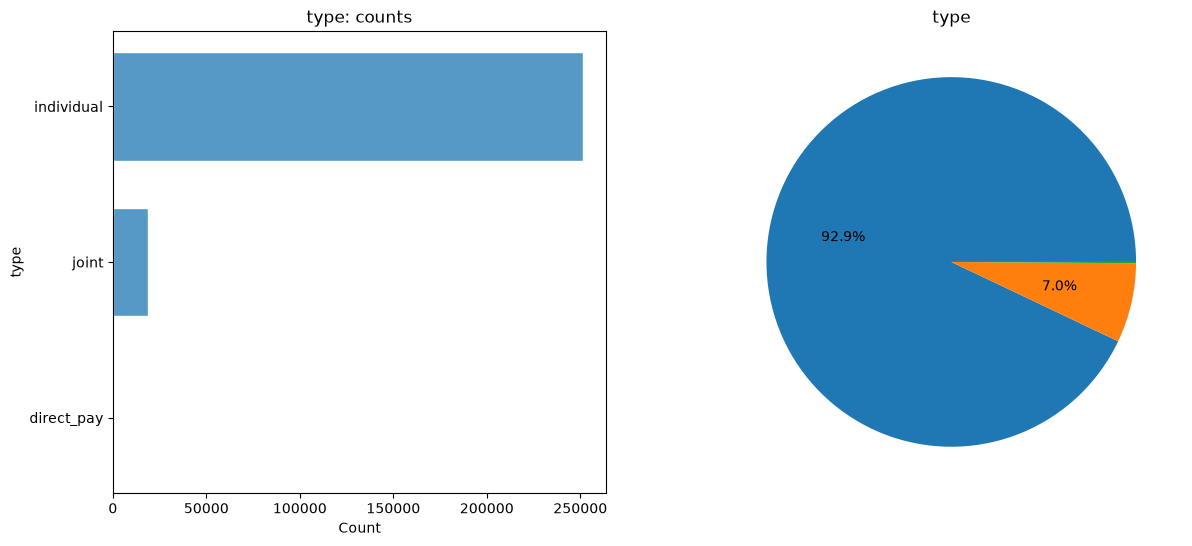

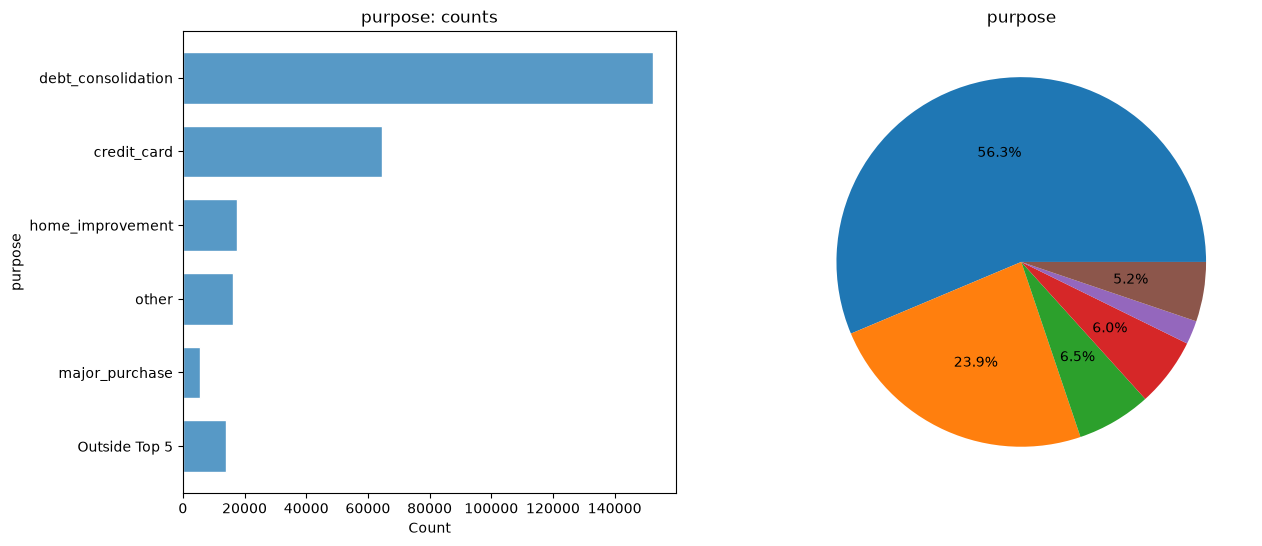

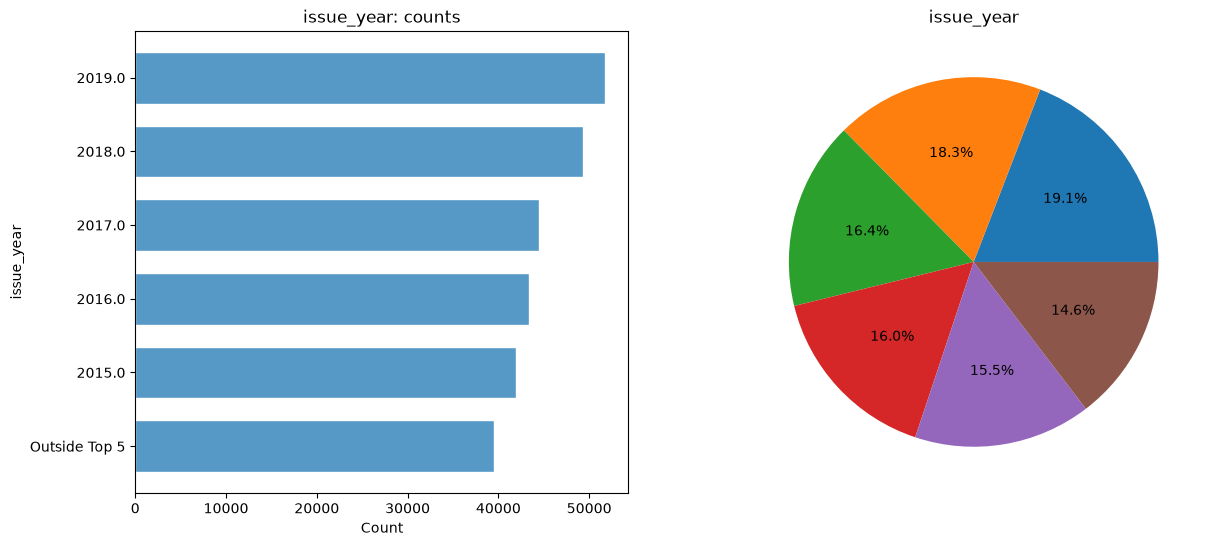

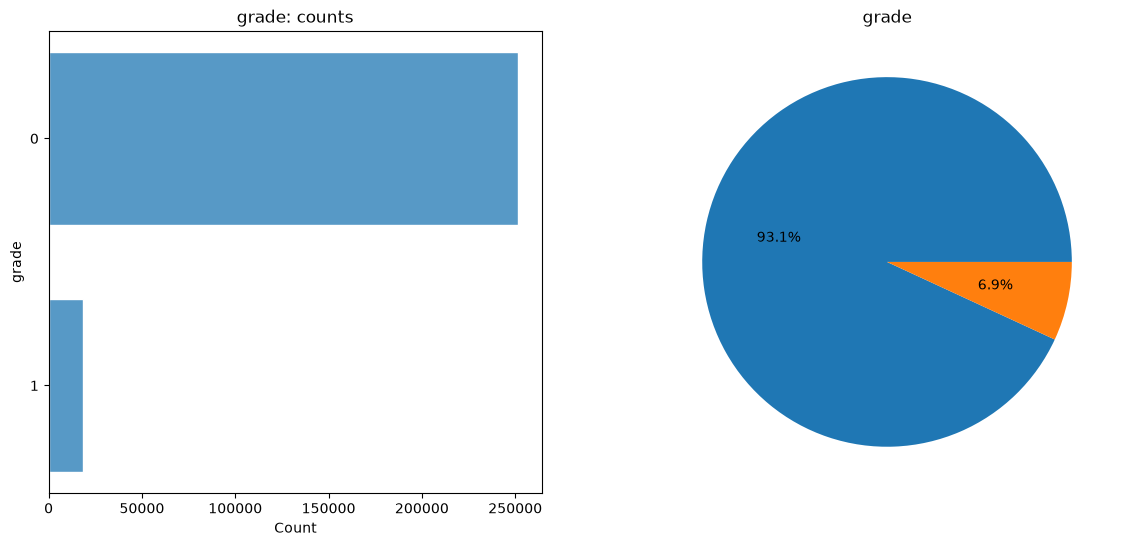

In [3]:
from univariate_analysis import bar_chart, pie_chart, histogram_by_class, boxplot_by_class

data = pd.read_csv("datasets/master.csv")

def group_grade(grade):
    grouping = {**{char.upper(): 0 for char in "ABCD"}, **{char.upper(): 1 for char in "EFG"}}
    return grade.replace(grouping)

data["grade"] = group_grade(data["grade"]).astype("str")
data["issue_year"] = data["issue_year"].astype("str")
data["emp_length"] = data["emp_length"].fillna("NaN")

DROP_COLUMNS = [
    "emp_title",         # too noisy (high-cardinality free text)
    "state",             # duplicate of addr_state
    "annual_inc_joint",  # too many missing values
    "customer_id",       # identifier, not predictive
    "loan_status",       # not meaningful information for prediction
    "int_rate"           # redundant information - not known at loan application time 
]
df = data.drop(columns=DROP_COLUMNS)

NUMERICAL_COLUMNS = ["annual_inc", "avg_cur_bal", "Tot_cur_bal", "loan_amount", "installment"]
CATEGORICAL_COLUMNS = ["emp_length", "home_ownership", "verification_status", "addr_state", "term", "type", "purpose", "issue_year",  "grade"]

for num_col in NUMERICAL_COLUMNS:
    fig, (hist_ax, box_ax) = plt.subplots(1, 2, figsize=(14, 5))
    histogram_by_class(df, num_col, ax=hist_ax)
    boxplot_by_class(df, num_col, ax=box_ax)
    plt.show()
    plt.close(fig)

for cat_col in CATEGORICAL_COLUMNS:
    fig, (bar_ax, pie_ax) = plt.subplots(1, 2, figsize=(14, 6))
    bar_chart(df, cat_col, ax=bar_ax, top_n=5)
    pie_chart(df, cat_col, ax=pie_ax, top_n=5, autopct=lambda p: f"{p:.1f}%" if p >= 3 else "")
    plt.show()
    plt.close(fig)

#data.to_csv("datasets/master_grade_grouped.csv")


## Comments from Analysis 
The top 0.01 percentile of `annual_inc` was studied. It was noted that even in the top percentiles of `annual_inc`, the amount of Class 1 entries remained relatively significant, at ~4.5% of the training samples.

Although state had the largest number of unique values, it is noted that the distribution of Grade 1 loans are relatively stratified among all the states. This can be seen after segregating the data by Grade 0 or Grade 1 loans and observing the composition of states in each class. There appears to be not much difference. If there is a correlation it must be non-linear, and would be best captured by a tree model.

The columns `annual_inc` and columns related to `balance` are extremely right skewed and fat tailed. A log transform is probably necessary or even a winsorisation to simply cut all the entries above a certain threshold. 

# Bivariate Analysis

Reuses the plotting functions from `bivariate_analysis.py`, segmenting by `grade` (the binary target) wherever the function supports a `target` argument.

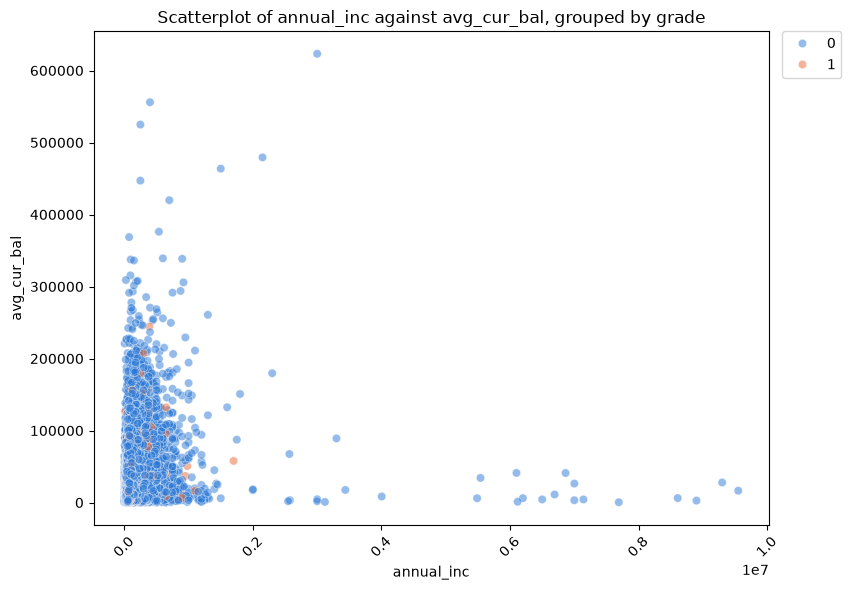

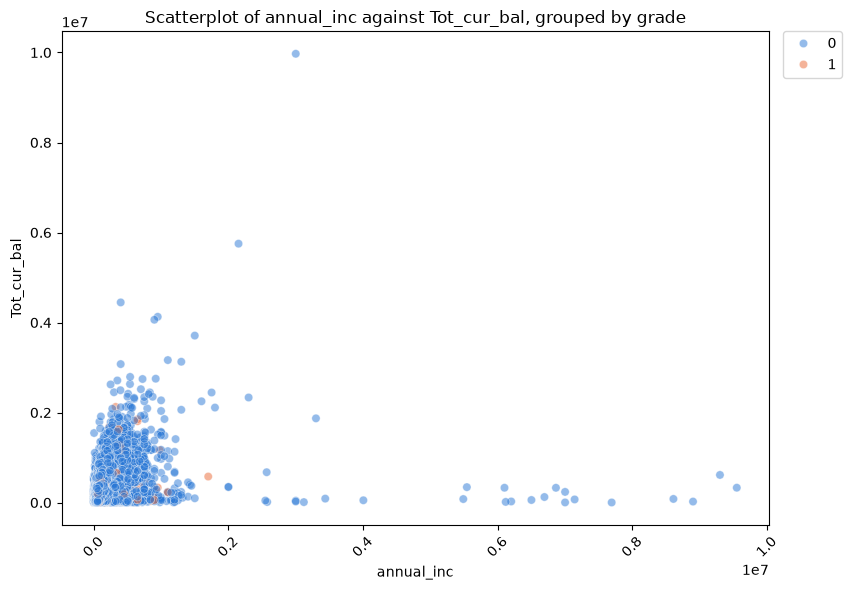

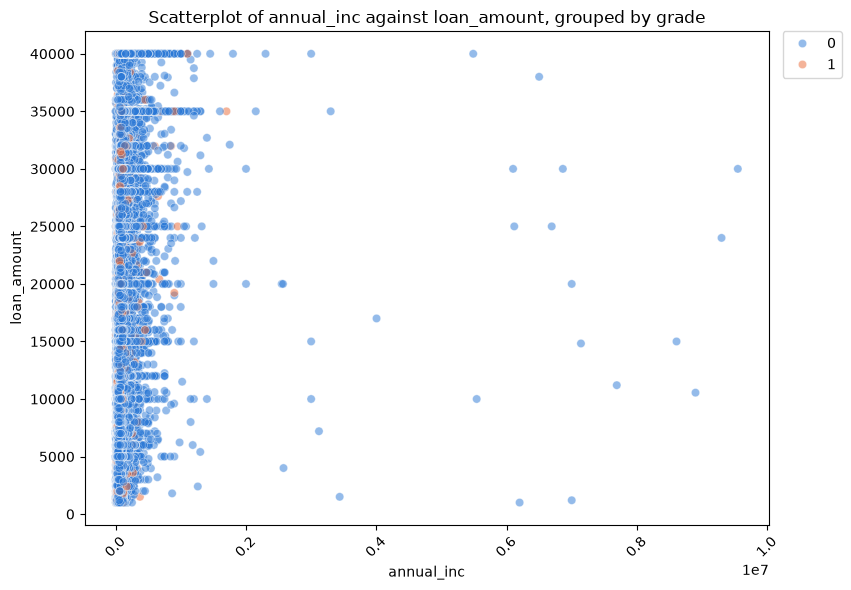

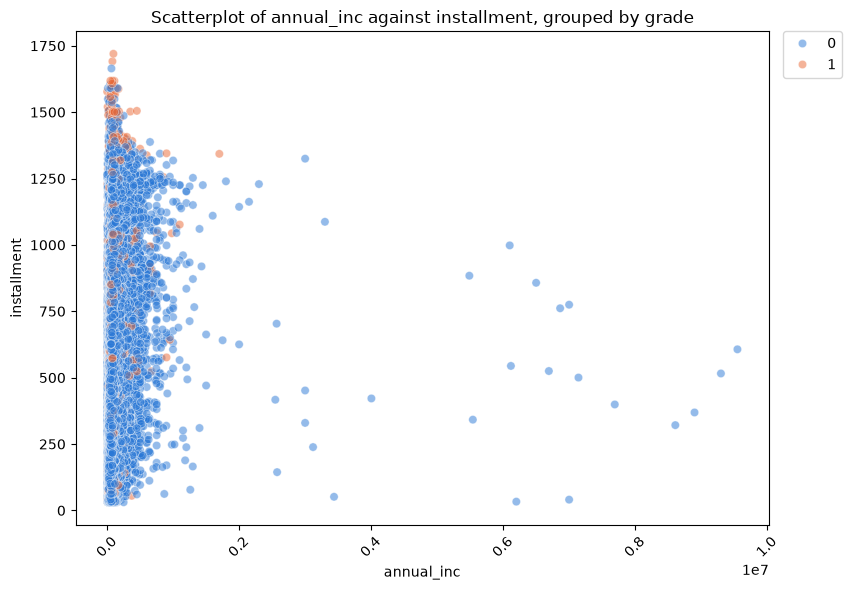

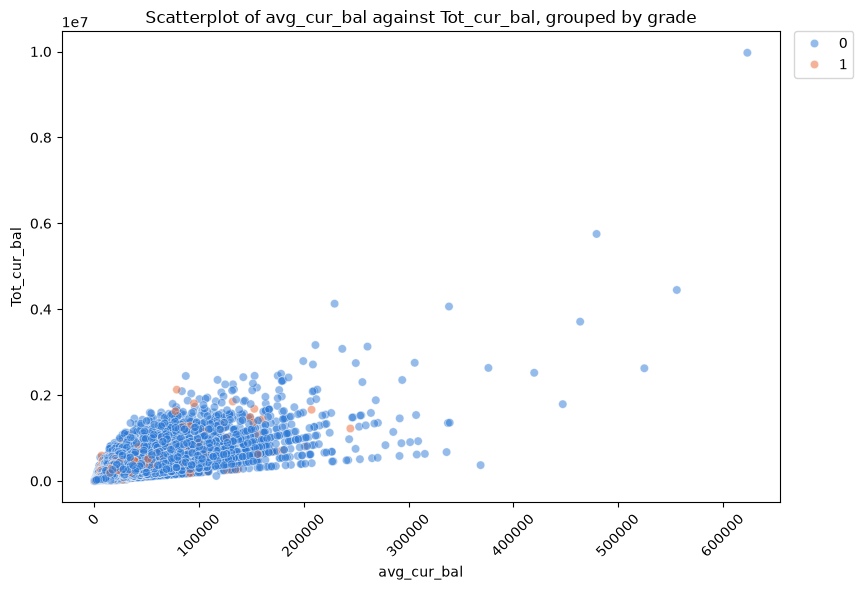

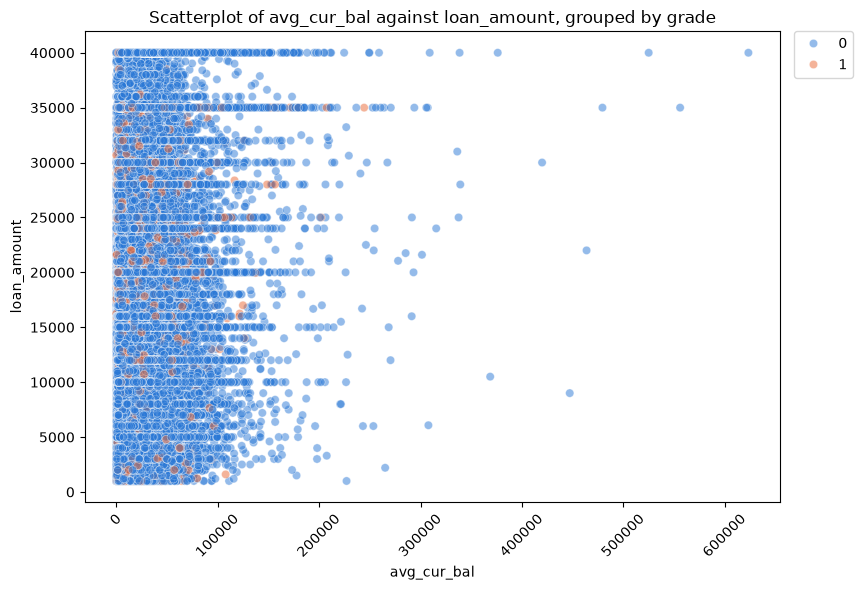

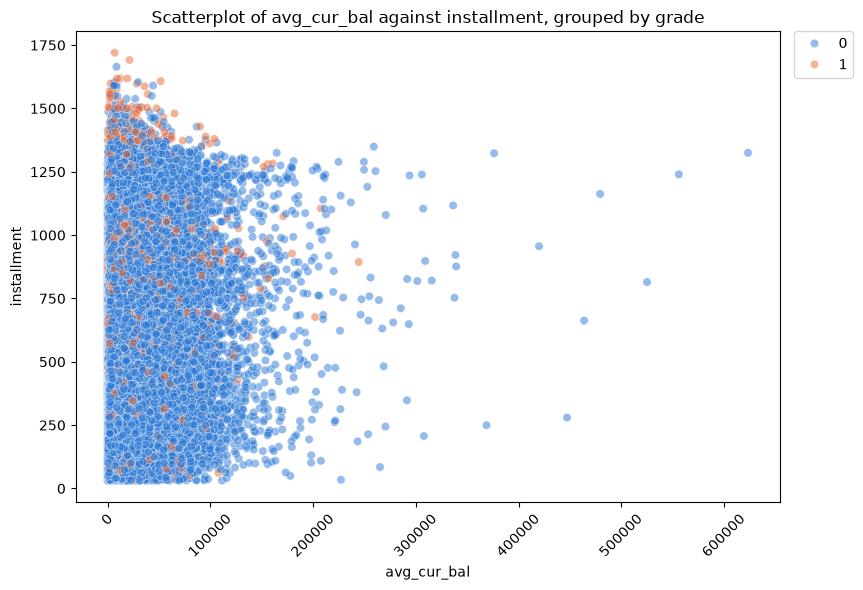

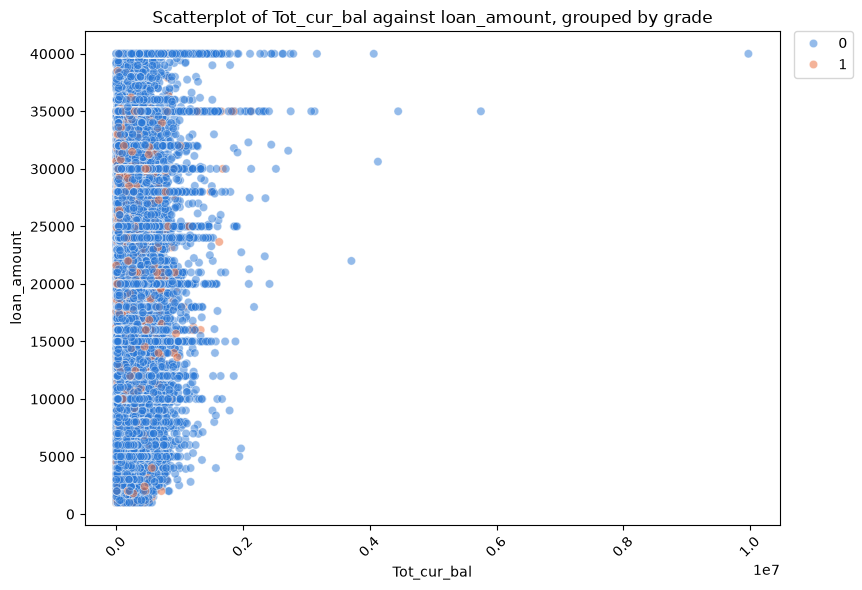

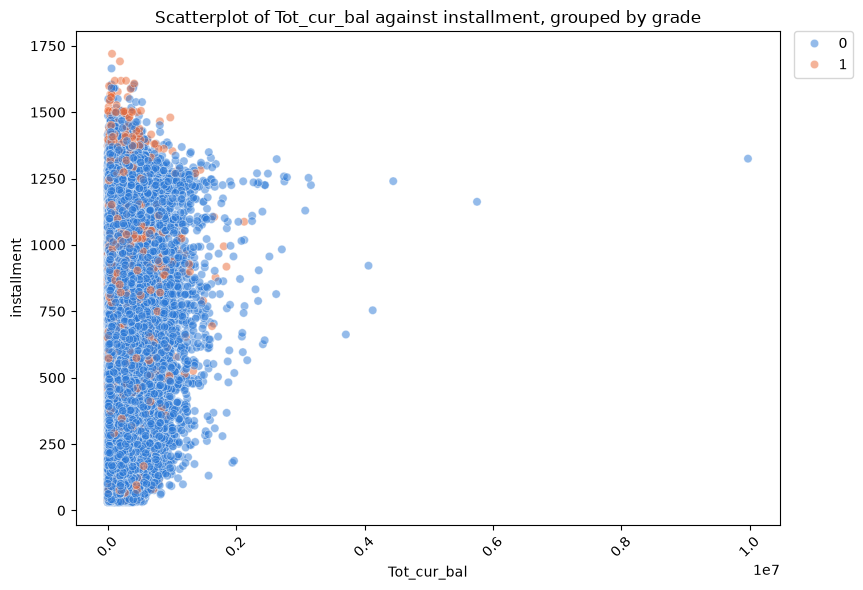

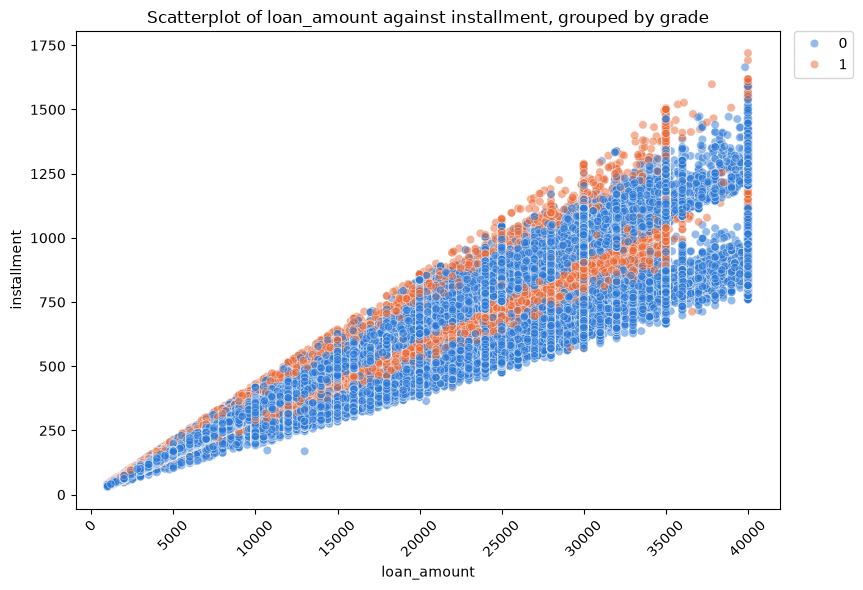

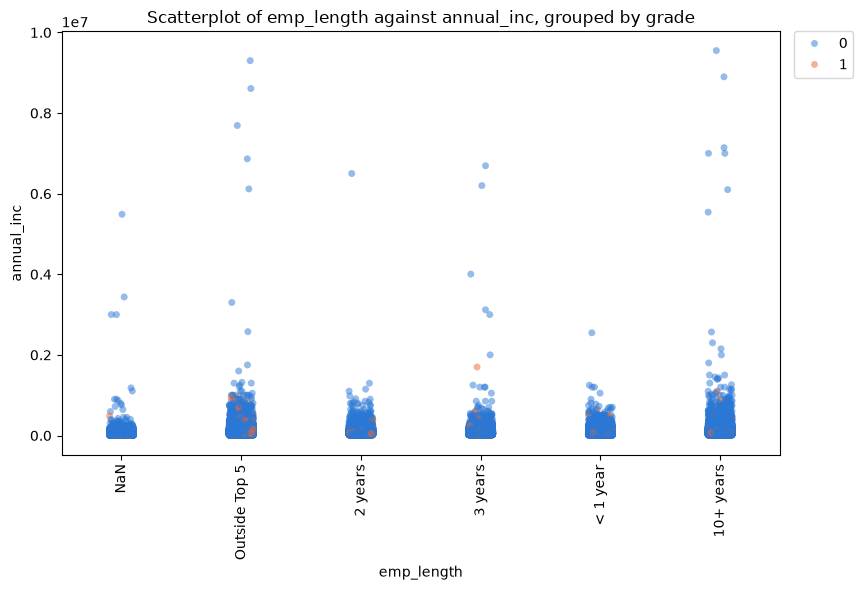

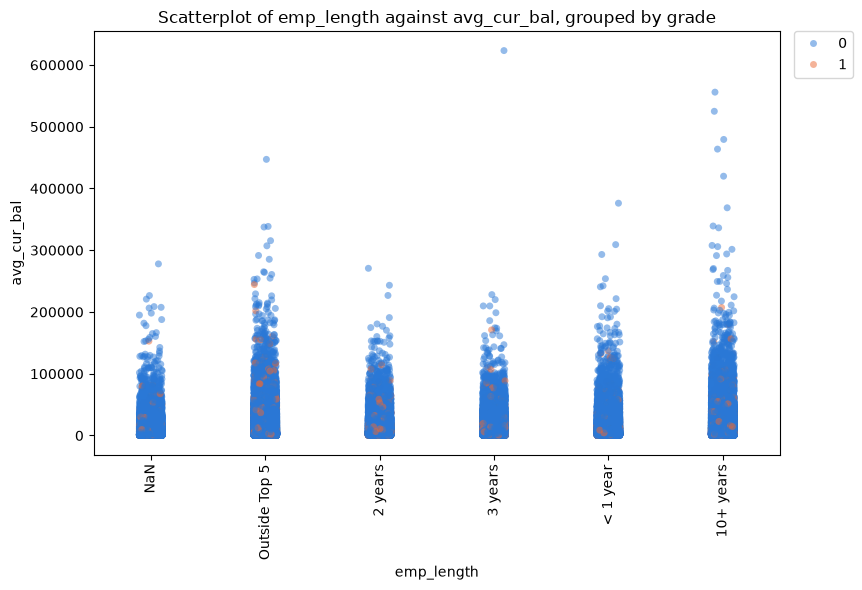

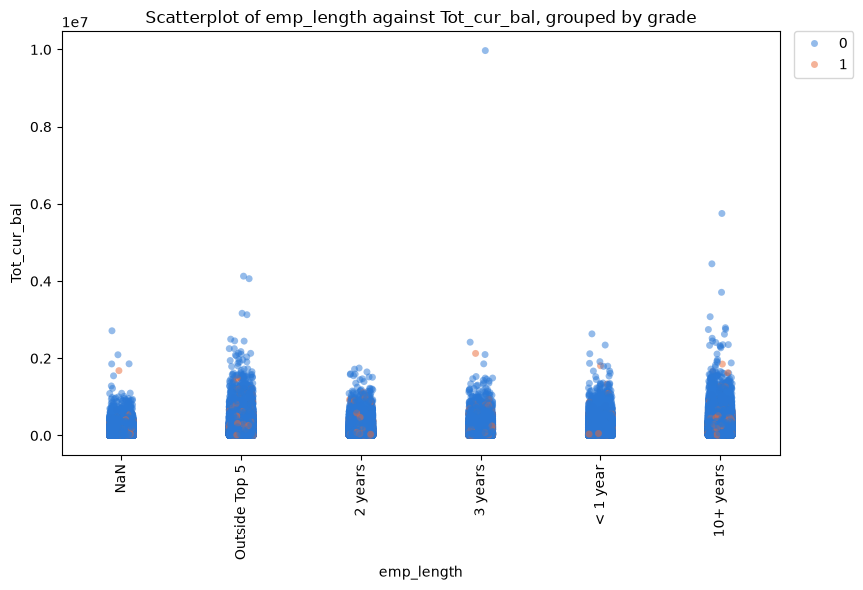

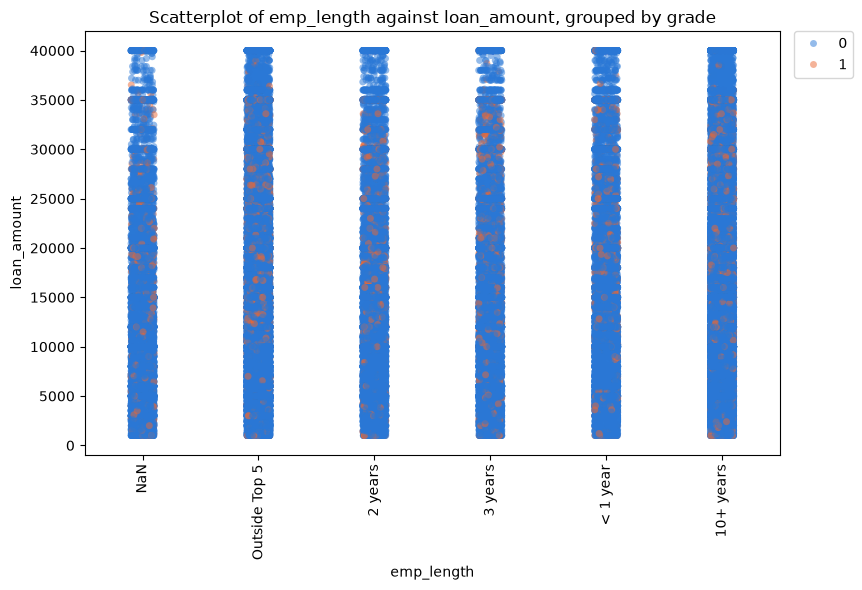

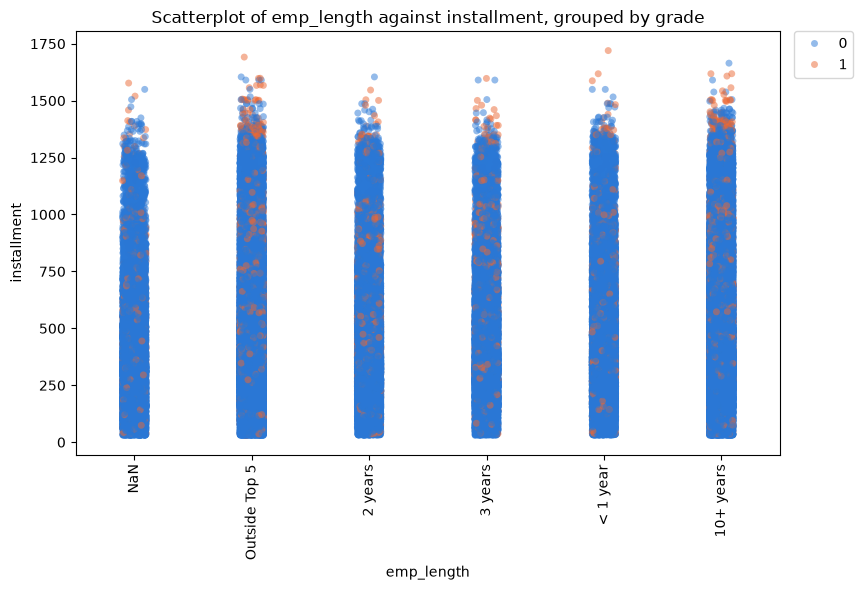

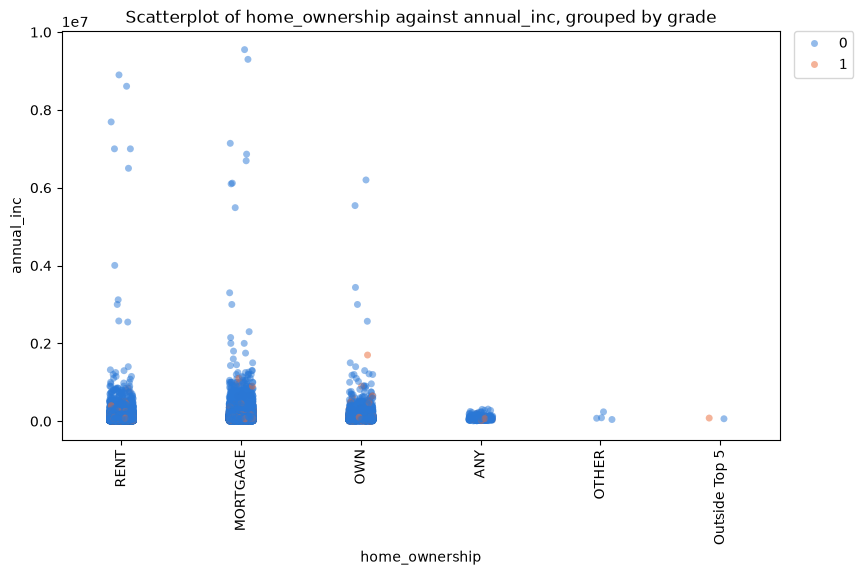

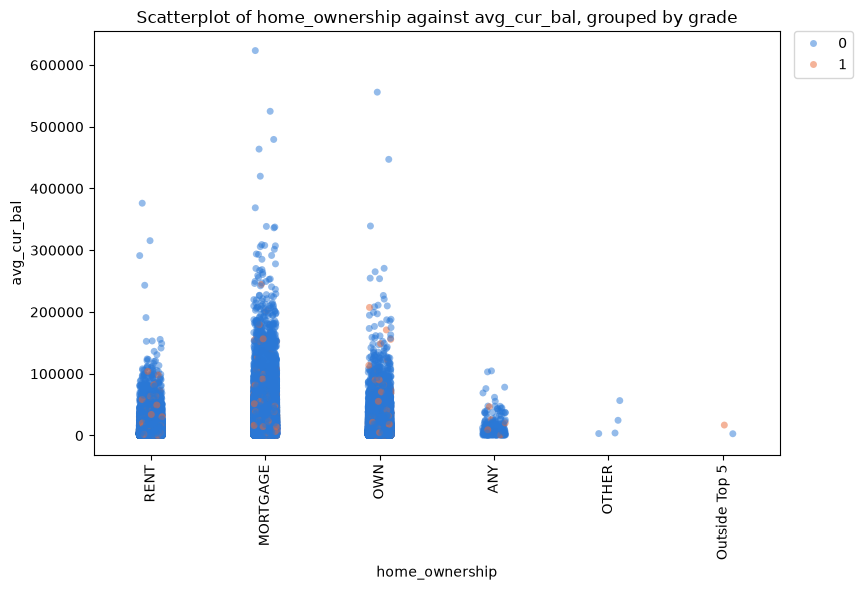

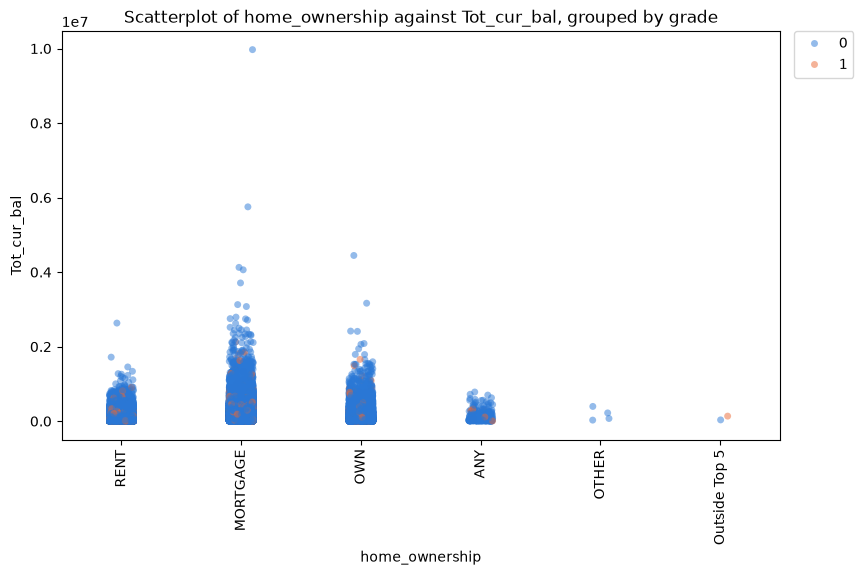

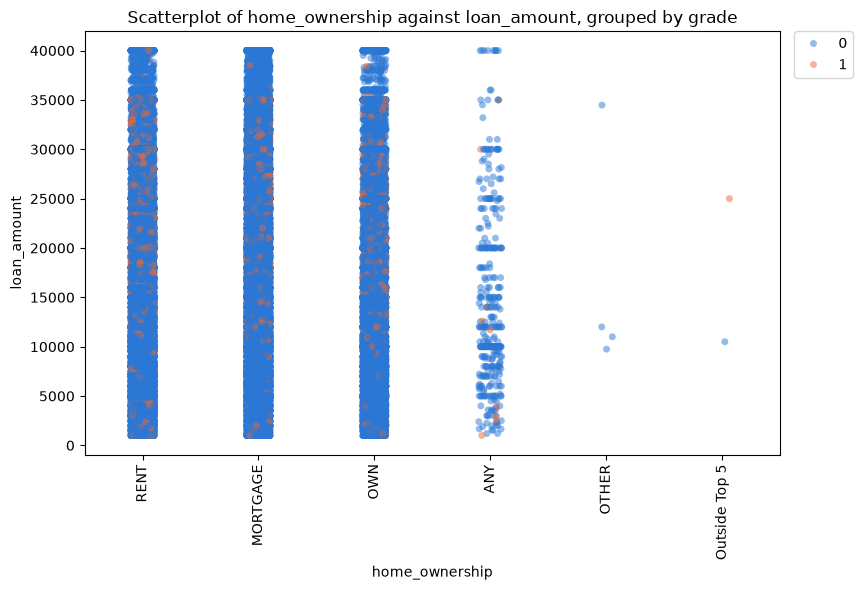

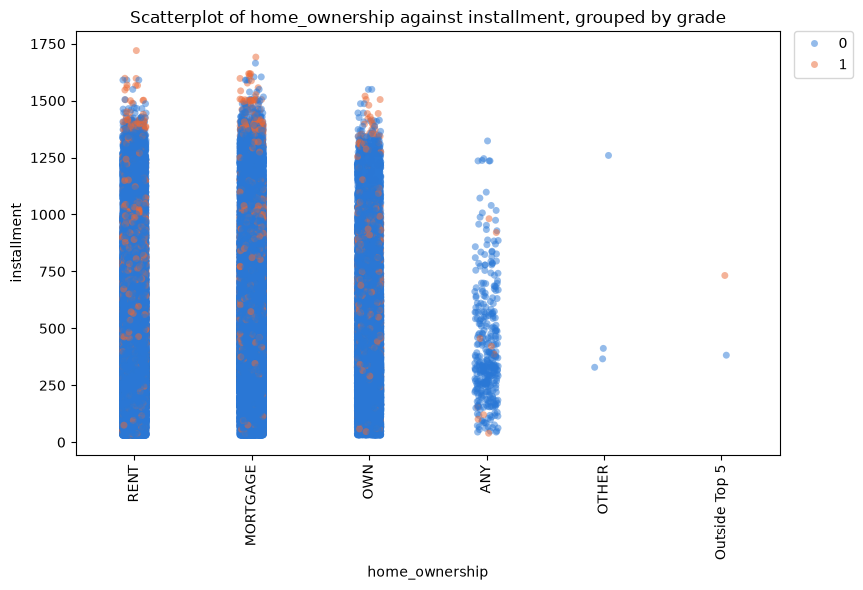

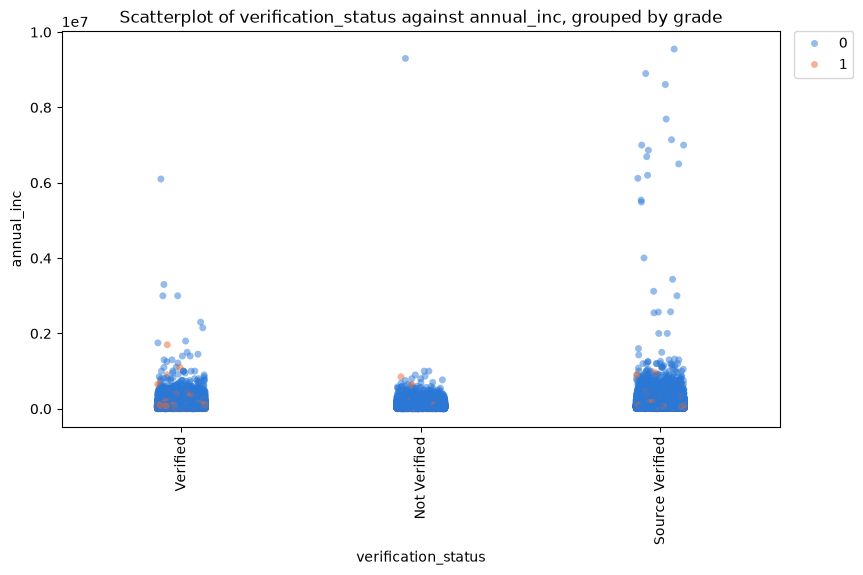

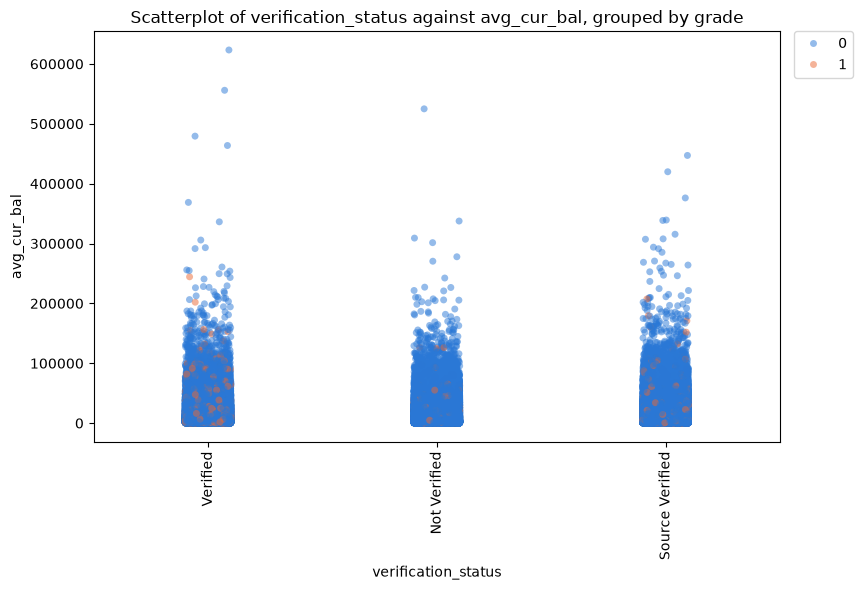

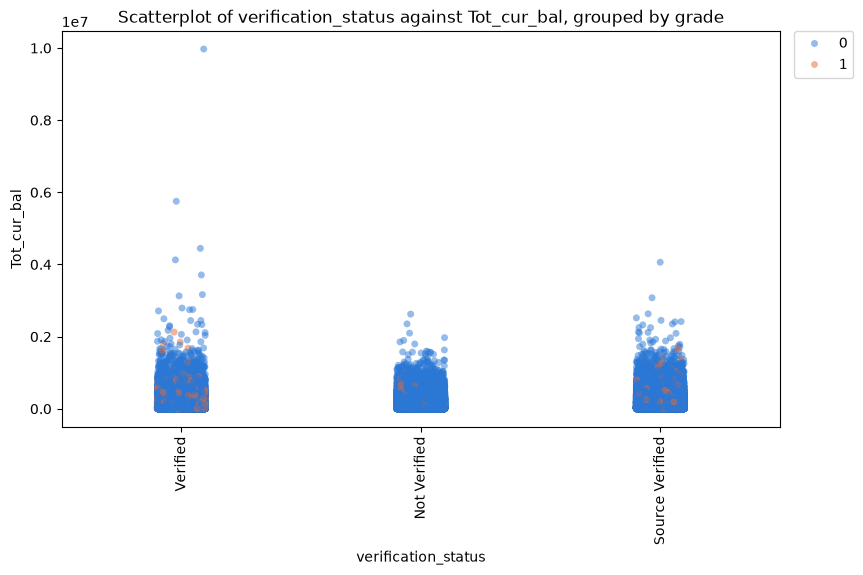

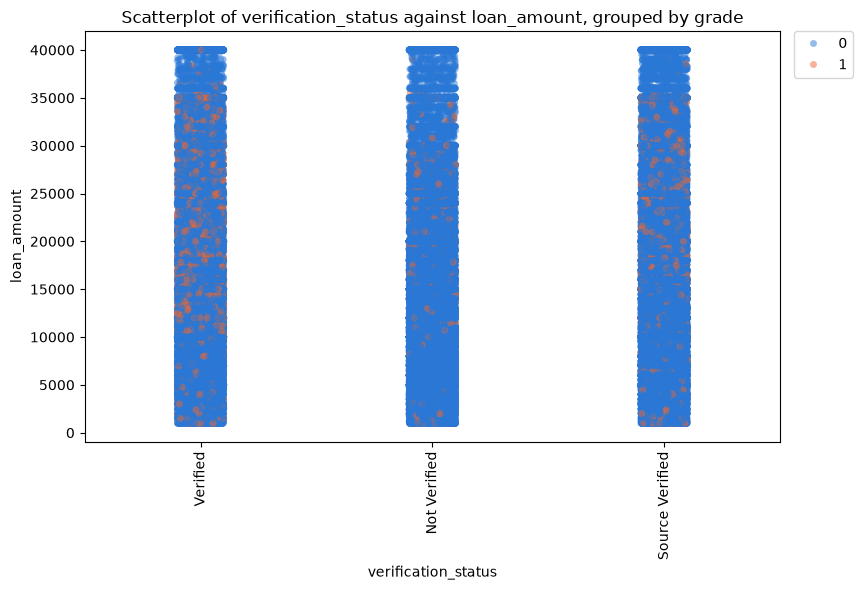

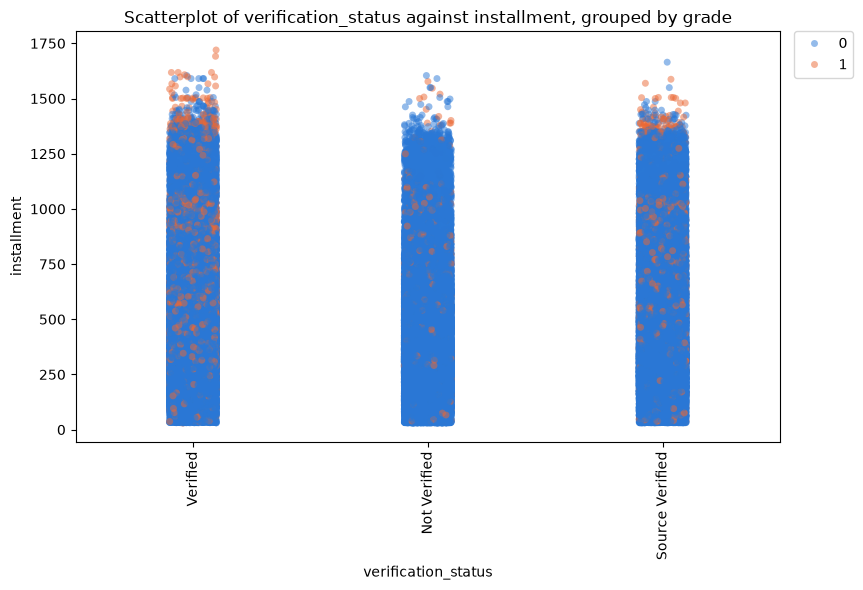

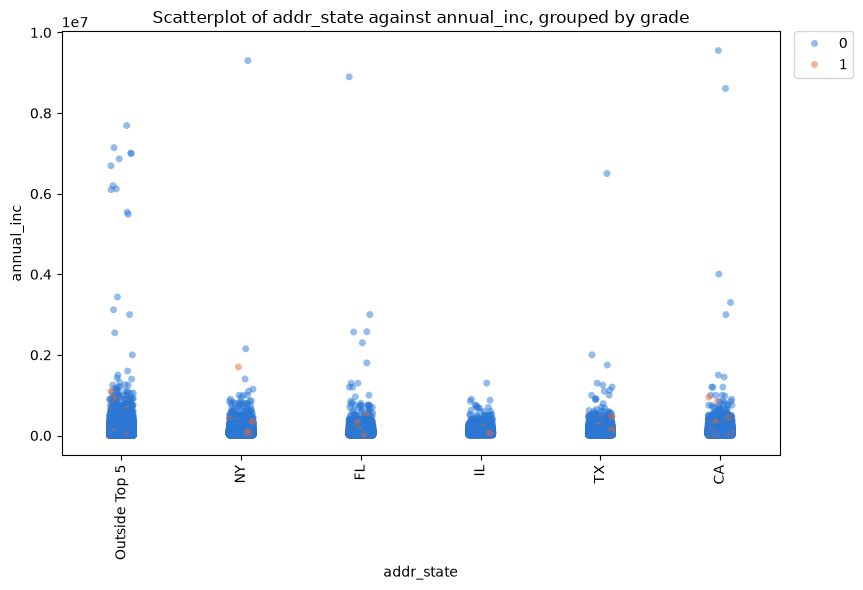

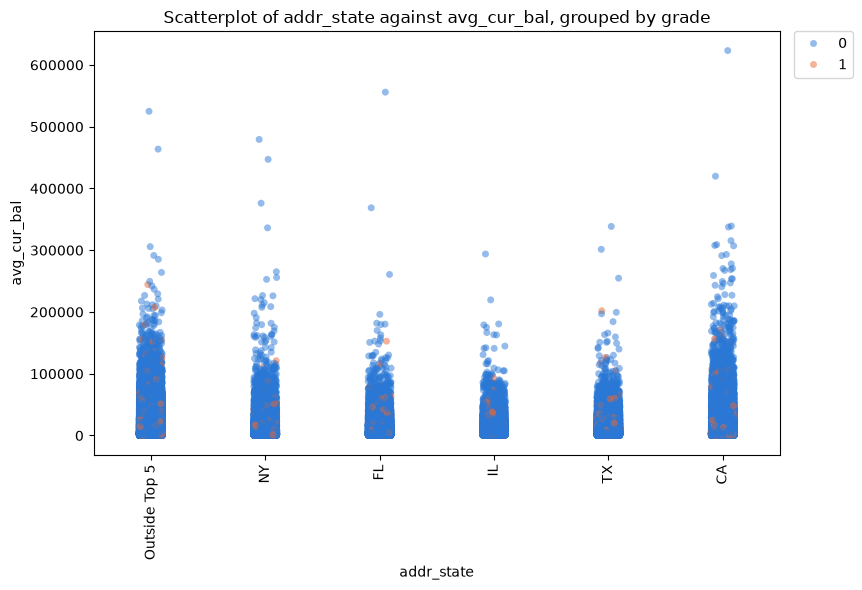

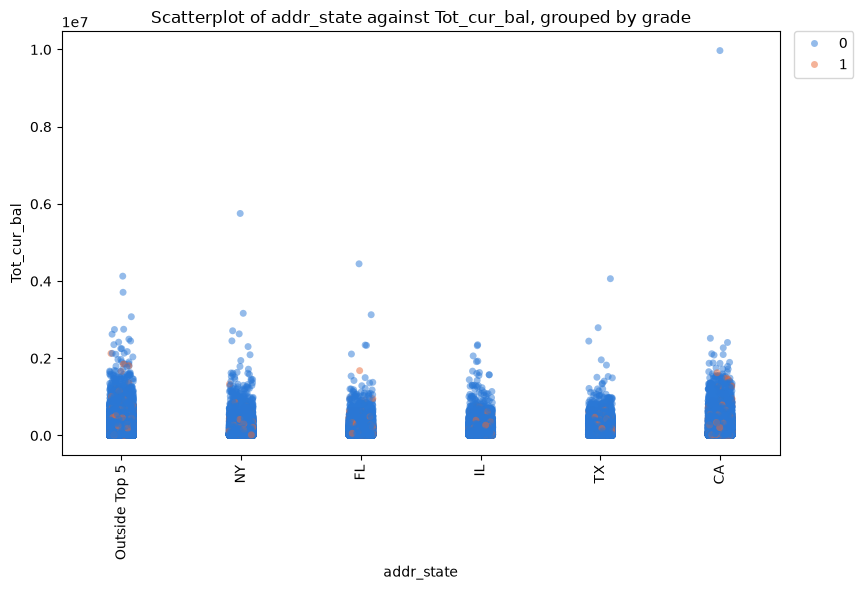

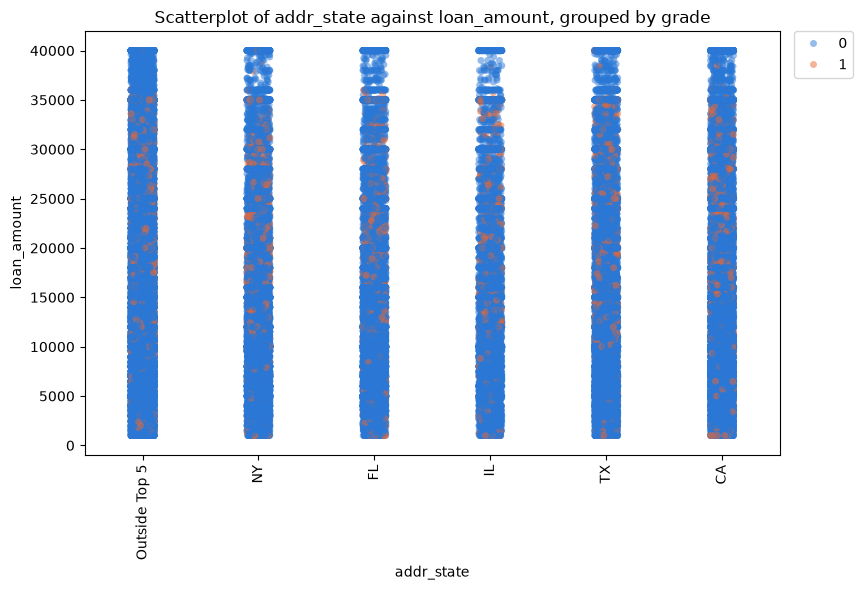

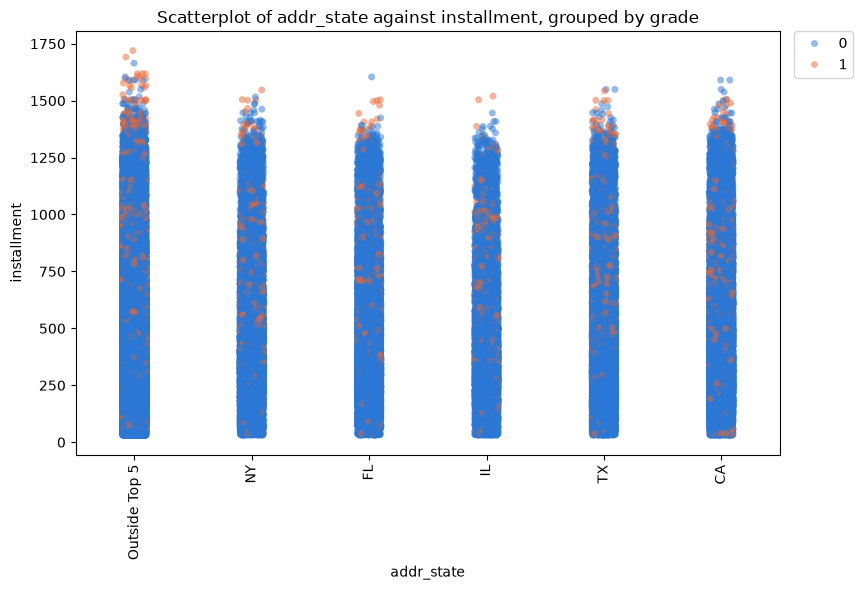

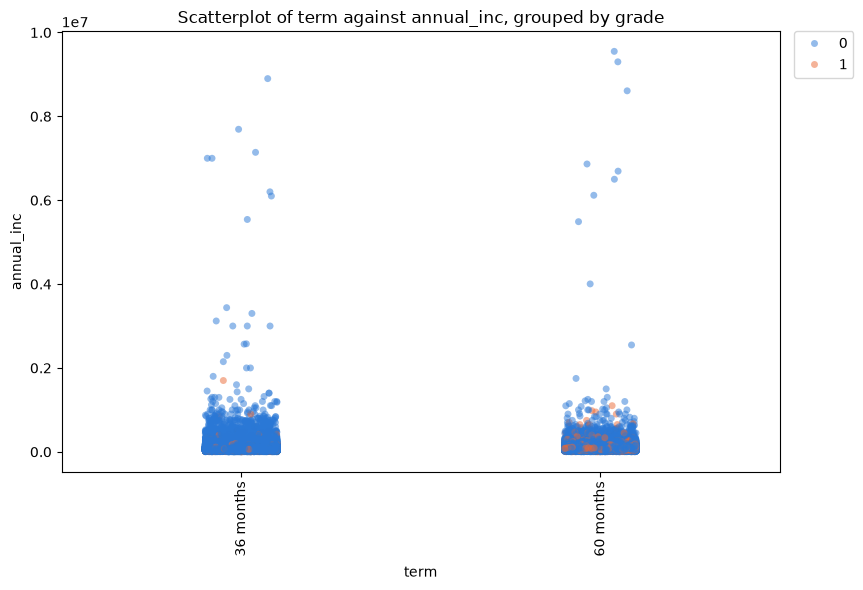

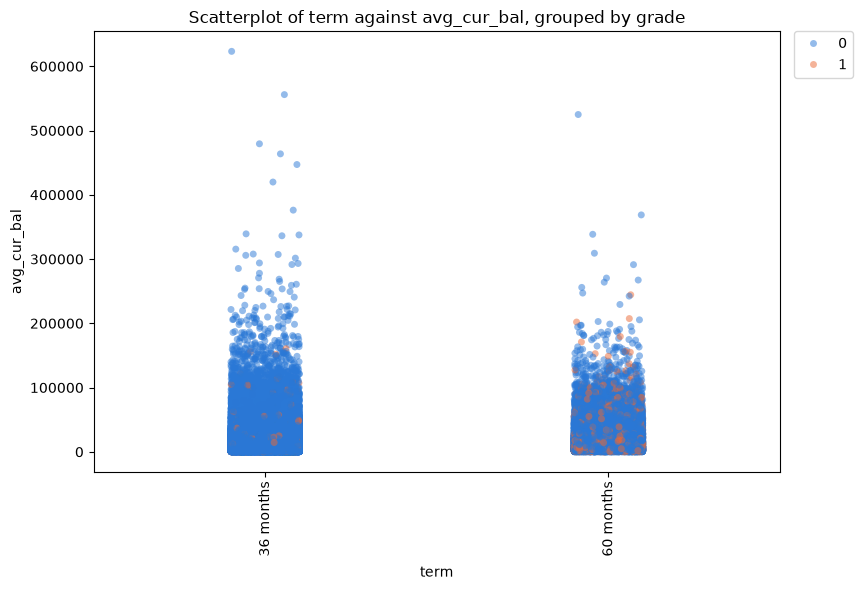

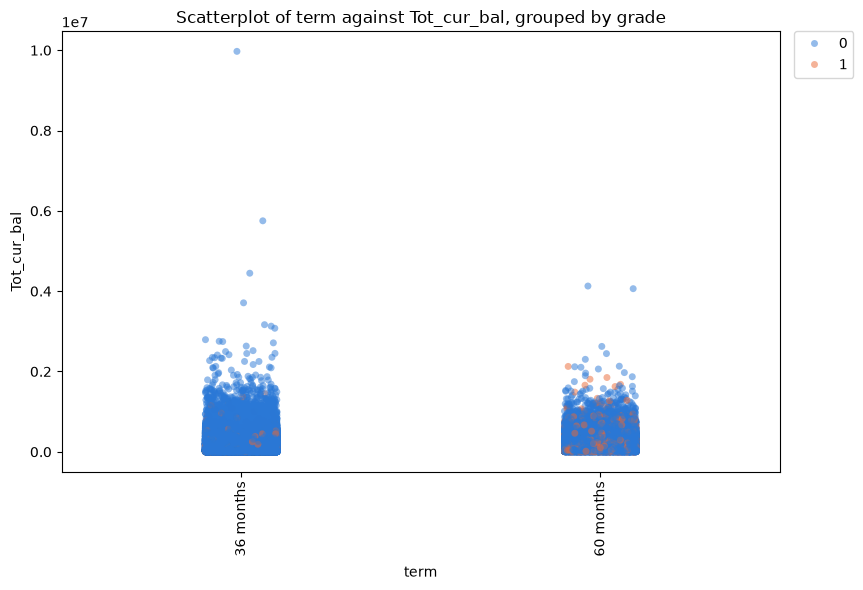

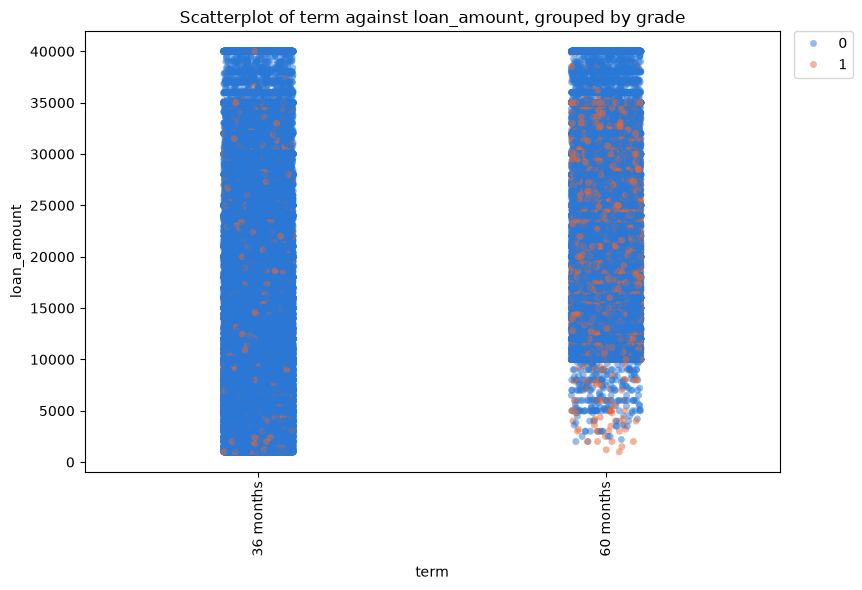

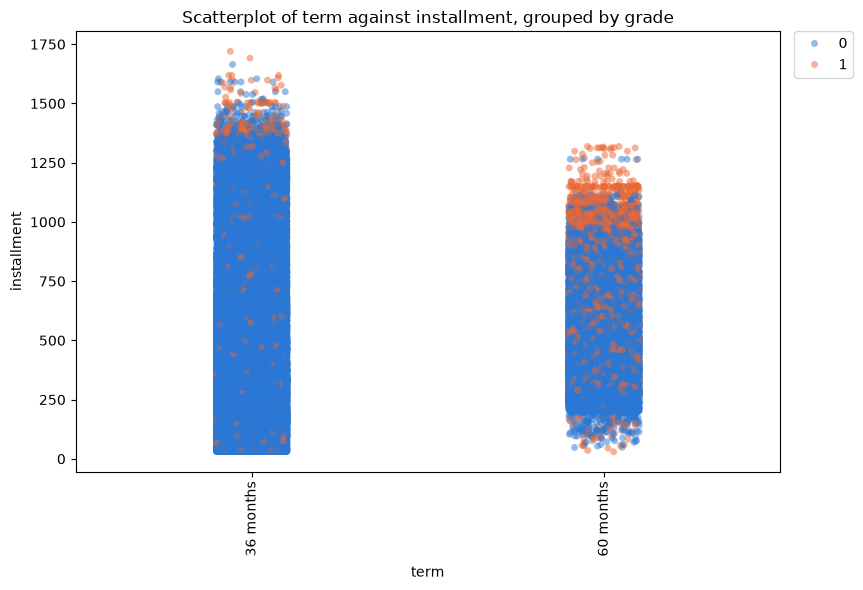

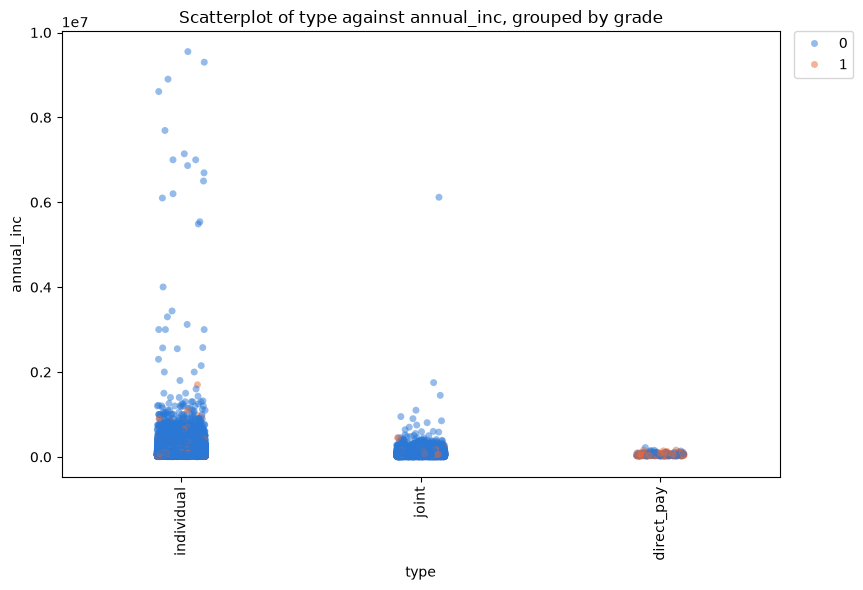

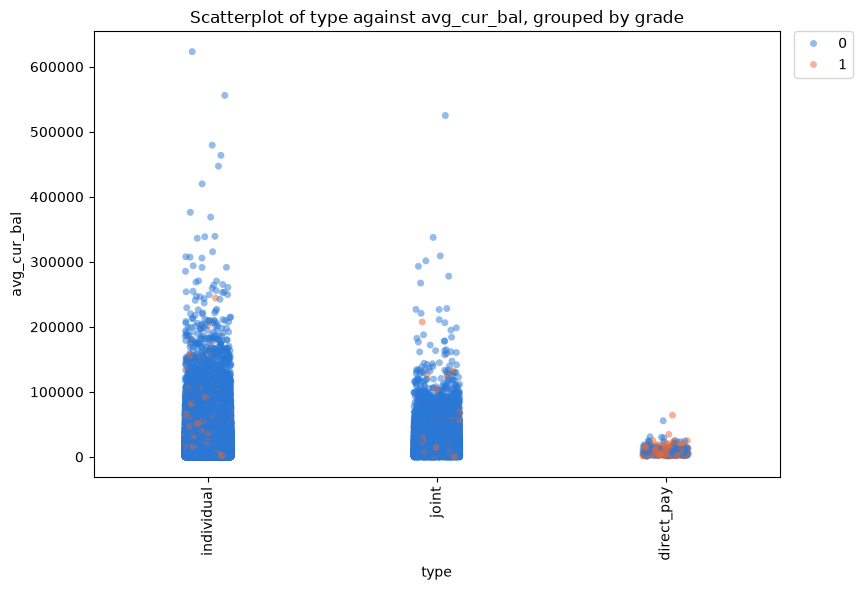

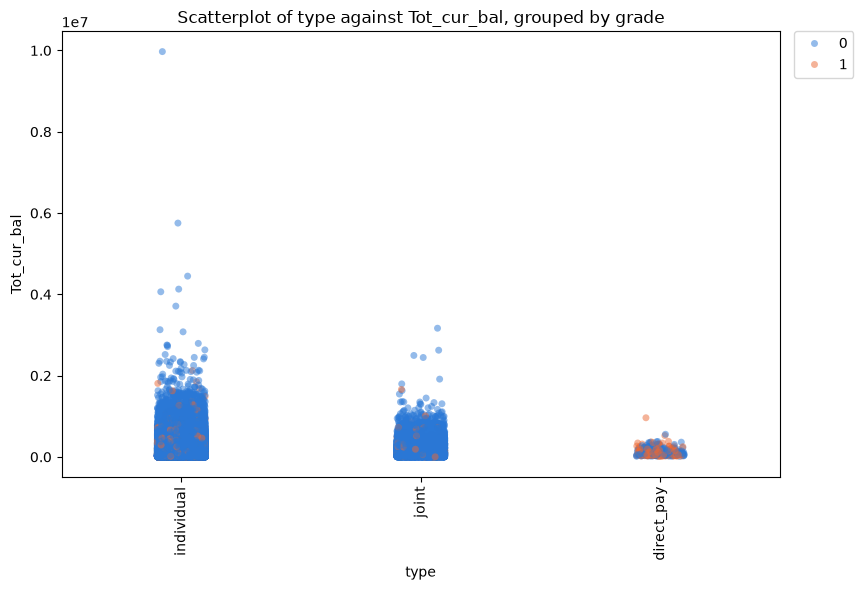

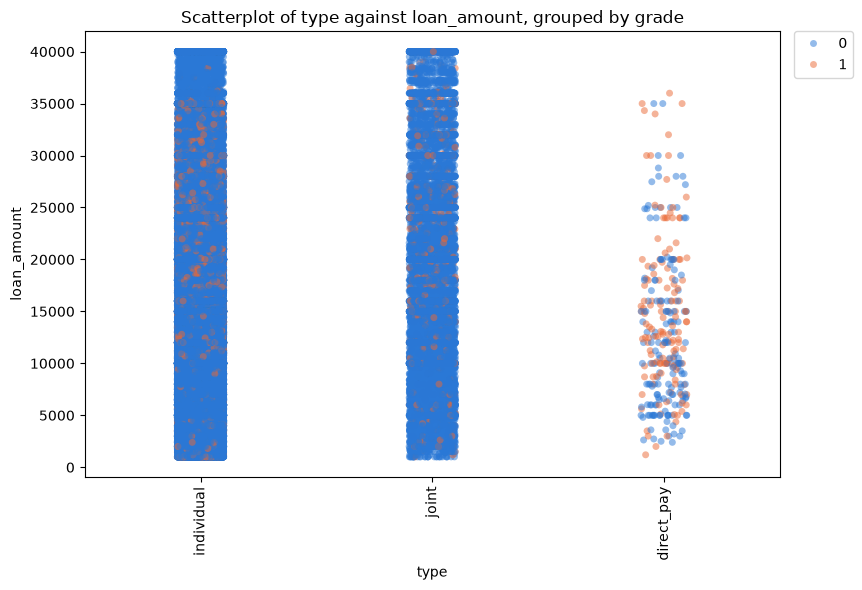

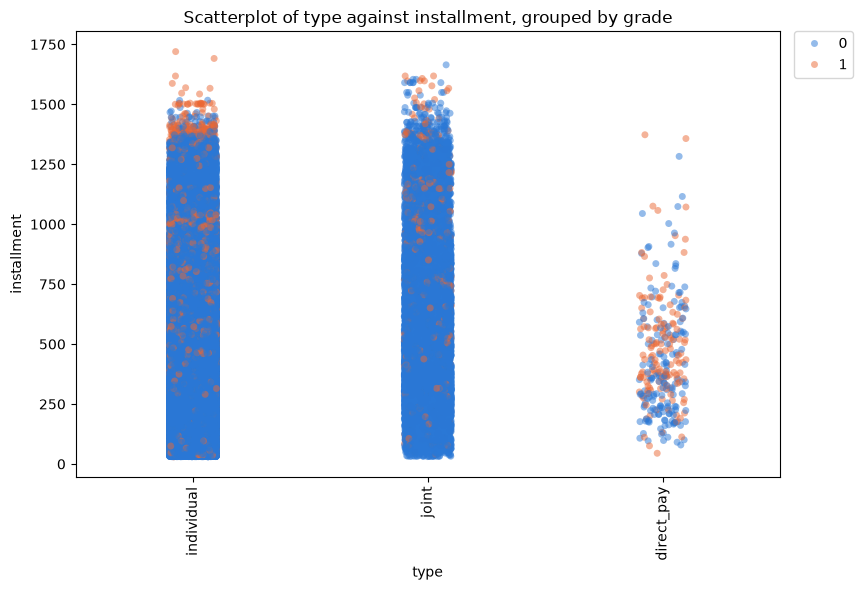

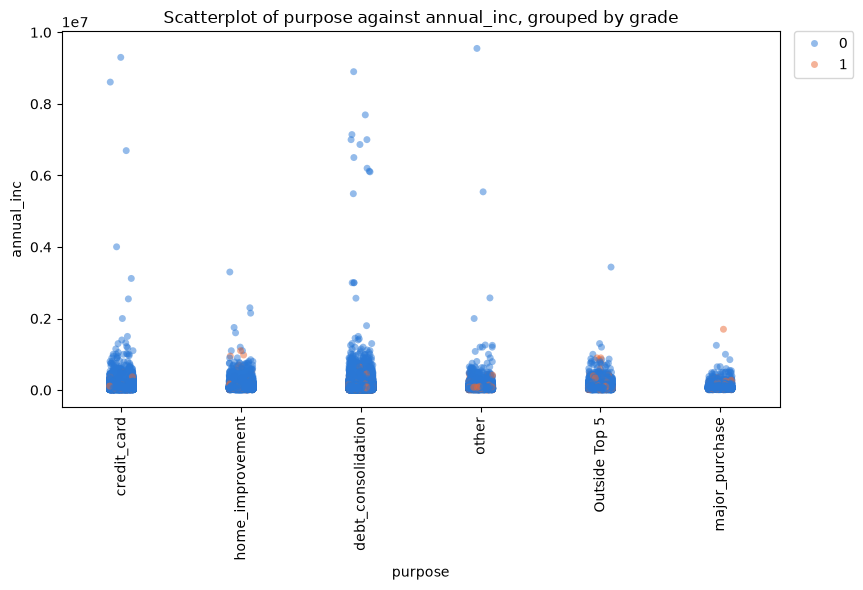

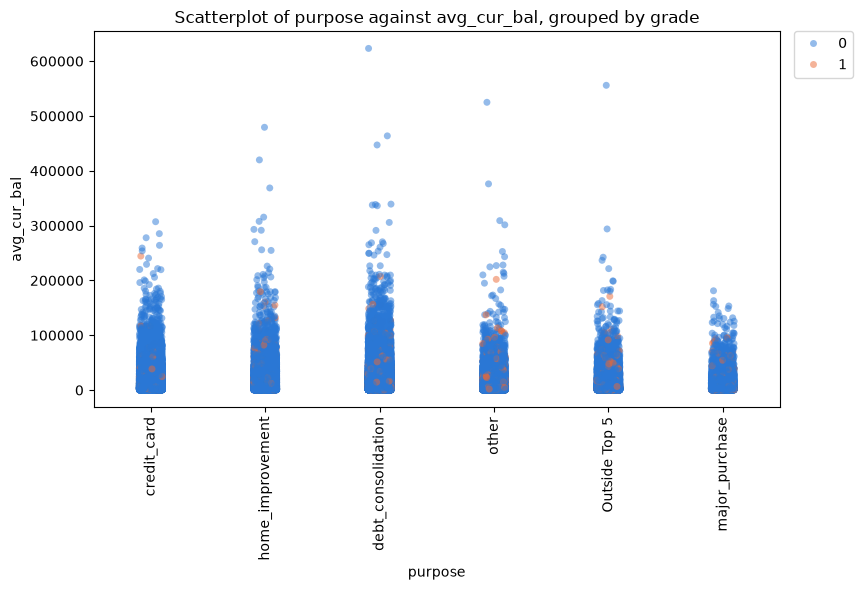

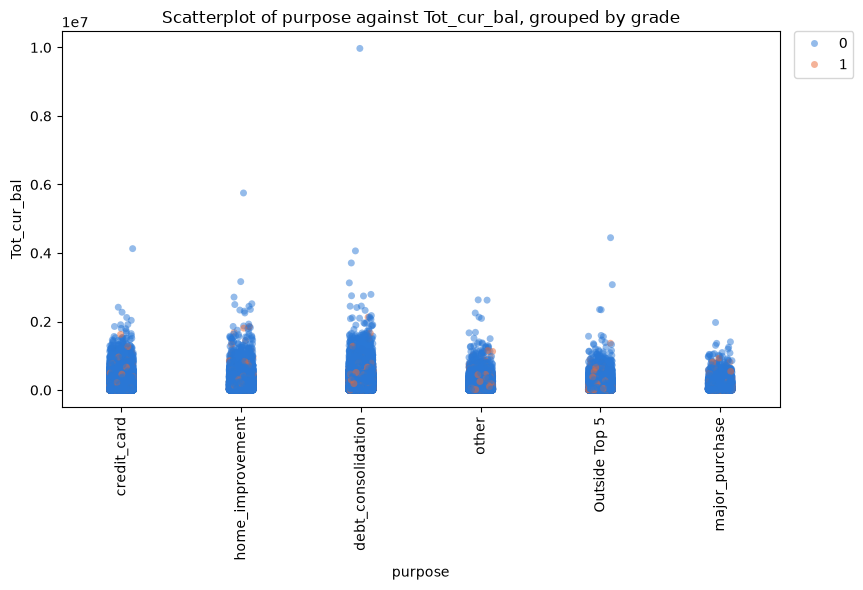

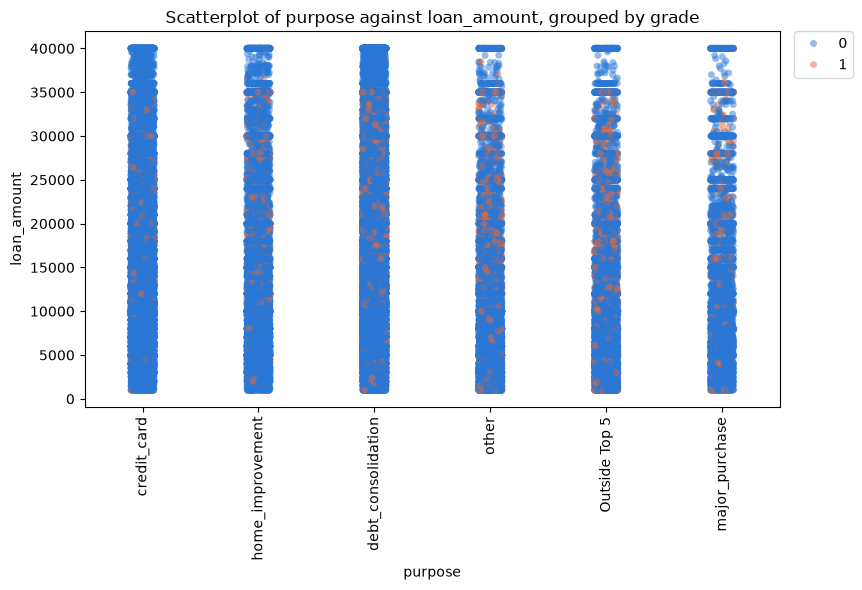

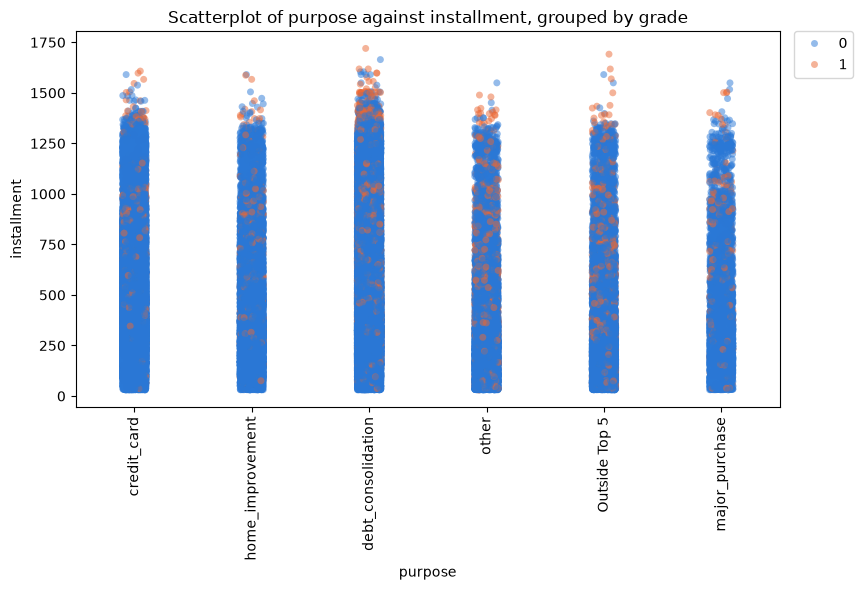

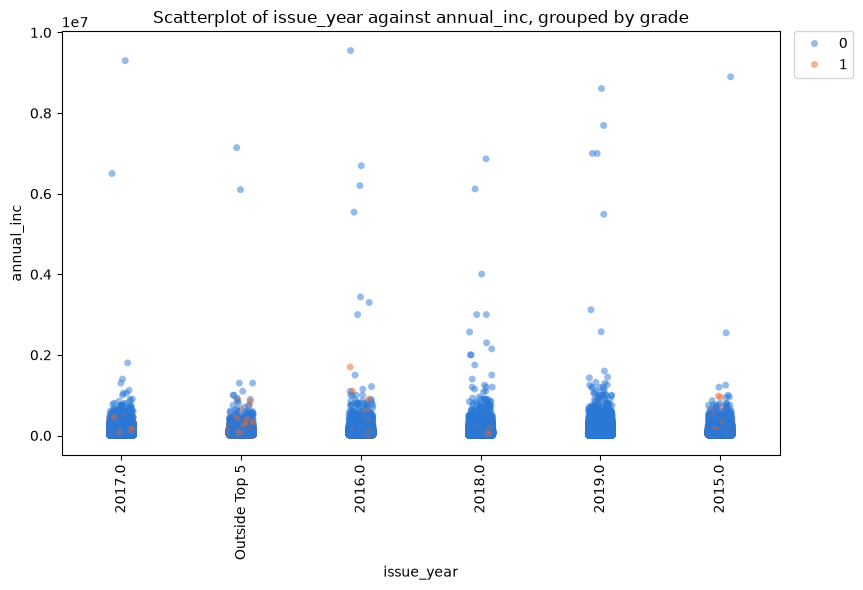

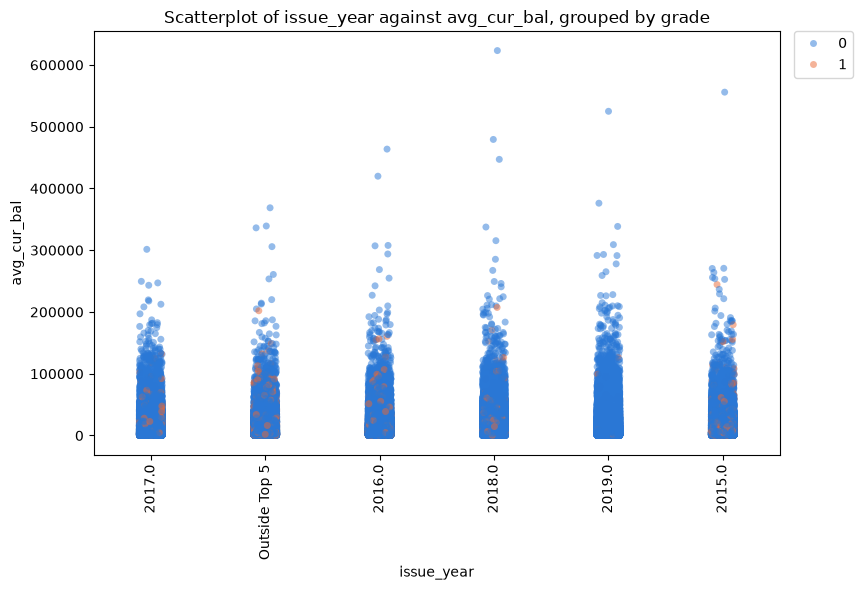

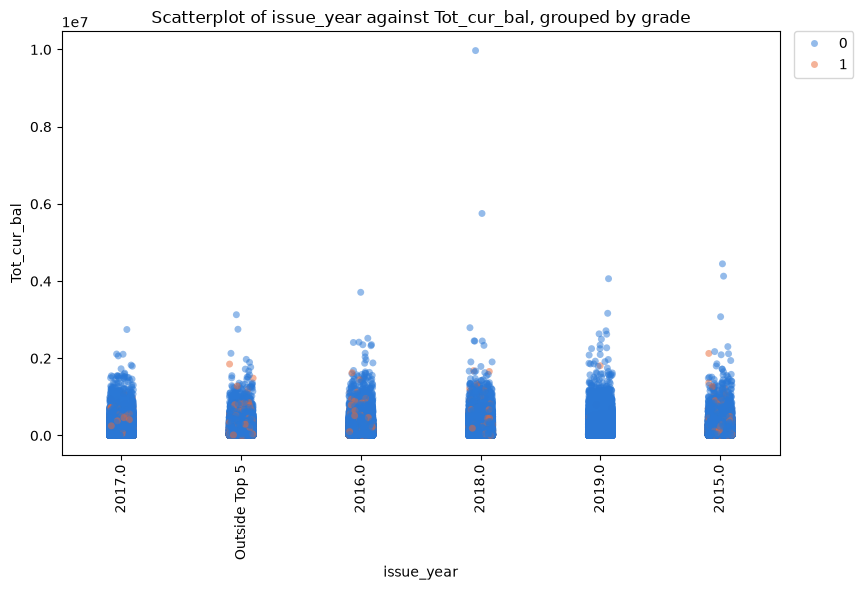

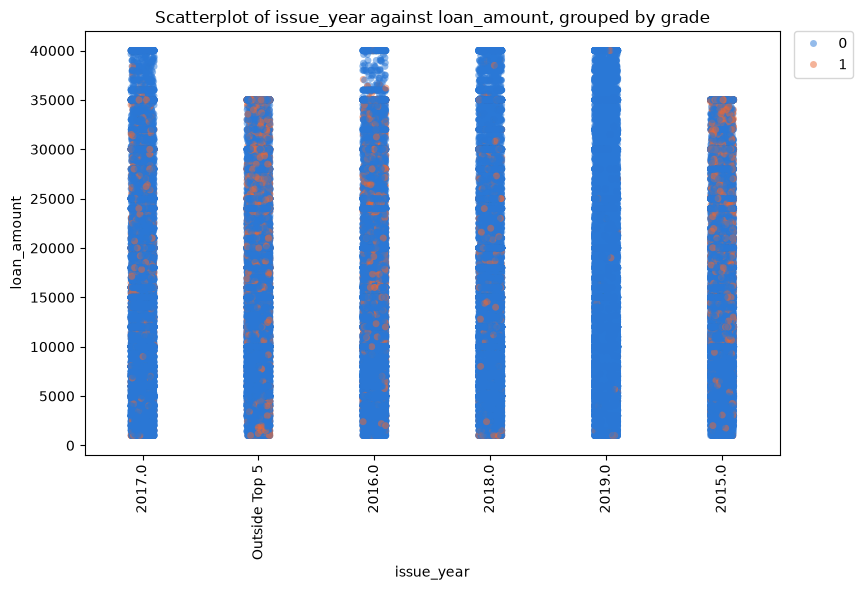

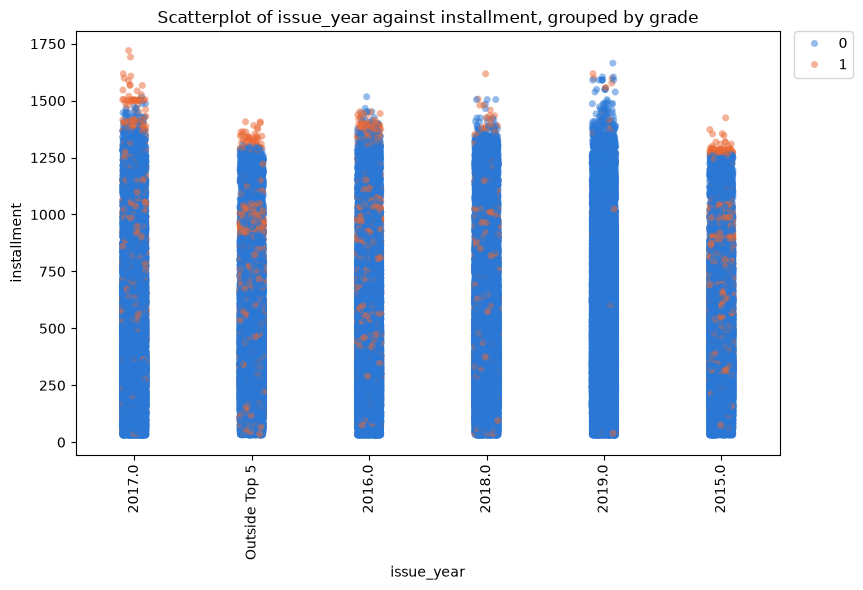

In [11]:
from itertools import combinations

from palette import CATEGORICAL_PALETTE
from univariate_analysis import _binary_classes
from bivariate_analysis import (
    numerical_and_numerical_scatter,
    categorical_and_numerical_scatter,
    categorical_and_categorical_box,
    categorical_and_categorical_count,
)

TARGET_COL = "grade"
BIVARIATE_CAT_COLS = [c for c in CATEGORICAL_COLUMNS if c != TARGET_COL]

majority_class, minority_class = _binary_classes(df, TARGET_COL)
palette = {majority_class: CATEGORICAL_PALETTE[0], minority_class: CATEGORICAL_PALETTE[1]}

#--- numerical x numerical ---
for num_col1, num_col2 in combinations(NUMERICAL_COLUMNS, 2):
    fig, ax = plt.subplots(figsize=(8, 6))
    numerical_and_numerical_scatter(df, num_col1, num_col2, ax=ax, target=TARGET_COL, palette=palette, alpha=0.5)
    plt.show()
    plt.close(fig)

# --- categorical x numerical ---
for cat_col in BIVARIATE_CAT_COLS:
    for num_col in NUMERICAL_COLUMNS:
        fig, ax = plt.subplots(figsize=(8, 6))
        categorical_and_numerical_scatter(
            df, cat_col, num_col, ax=ax, target=TARGET_COL, top_n=5, palette=palette, alpha=0.5, 
        )
        plt.show()
        plt.close(fig)

# --- categorical x categorical ---
# for cat_col1, cat_col2 in combinations(BIVARIATE_CAT_COLS, 2):
#     fig, (ax_rate, ax_count) = plt.subplots(1, 2, figsize=(16, 6))
#     categorical_and_categorical_box(df, cat_col1, cat_col2, ax=ax_rate, target=TARGET_COL)
#     categorical_and_categorical_count(df, cat_col1, cat_col2, ax=ax_count)
#     plt.show()
#     plt.close(fig)

## Next Steps For Analysis

- The numerical columns MUST be winsorised/log-transformed in order to plot a more meaningful distribution. I may even cut it at the 75\% percentile.
- The bivariate columns require a boxplot to put into context the distributions of the current observations. 
- Installment appears to be an important predictor of loan grade that will be included as a factor. But perhaps there is a process meaningful reason why the person is asked to pay some instalment. 
- Current balance columns are basically duplicates and might be worth being dropped. 

Variables that appear to be economically meaningful:
- Installment 
- Term
- Average current balance/total current balance


